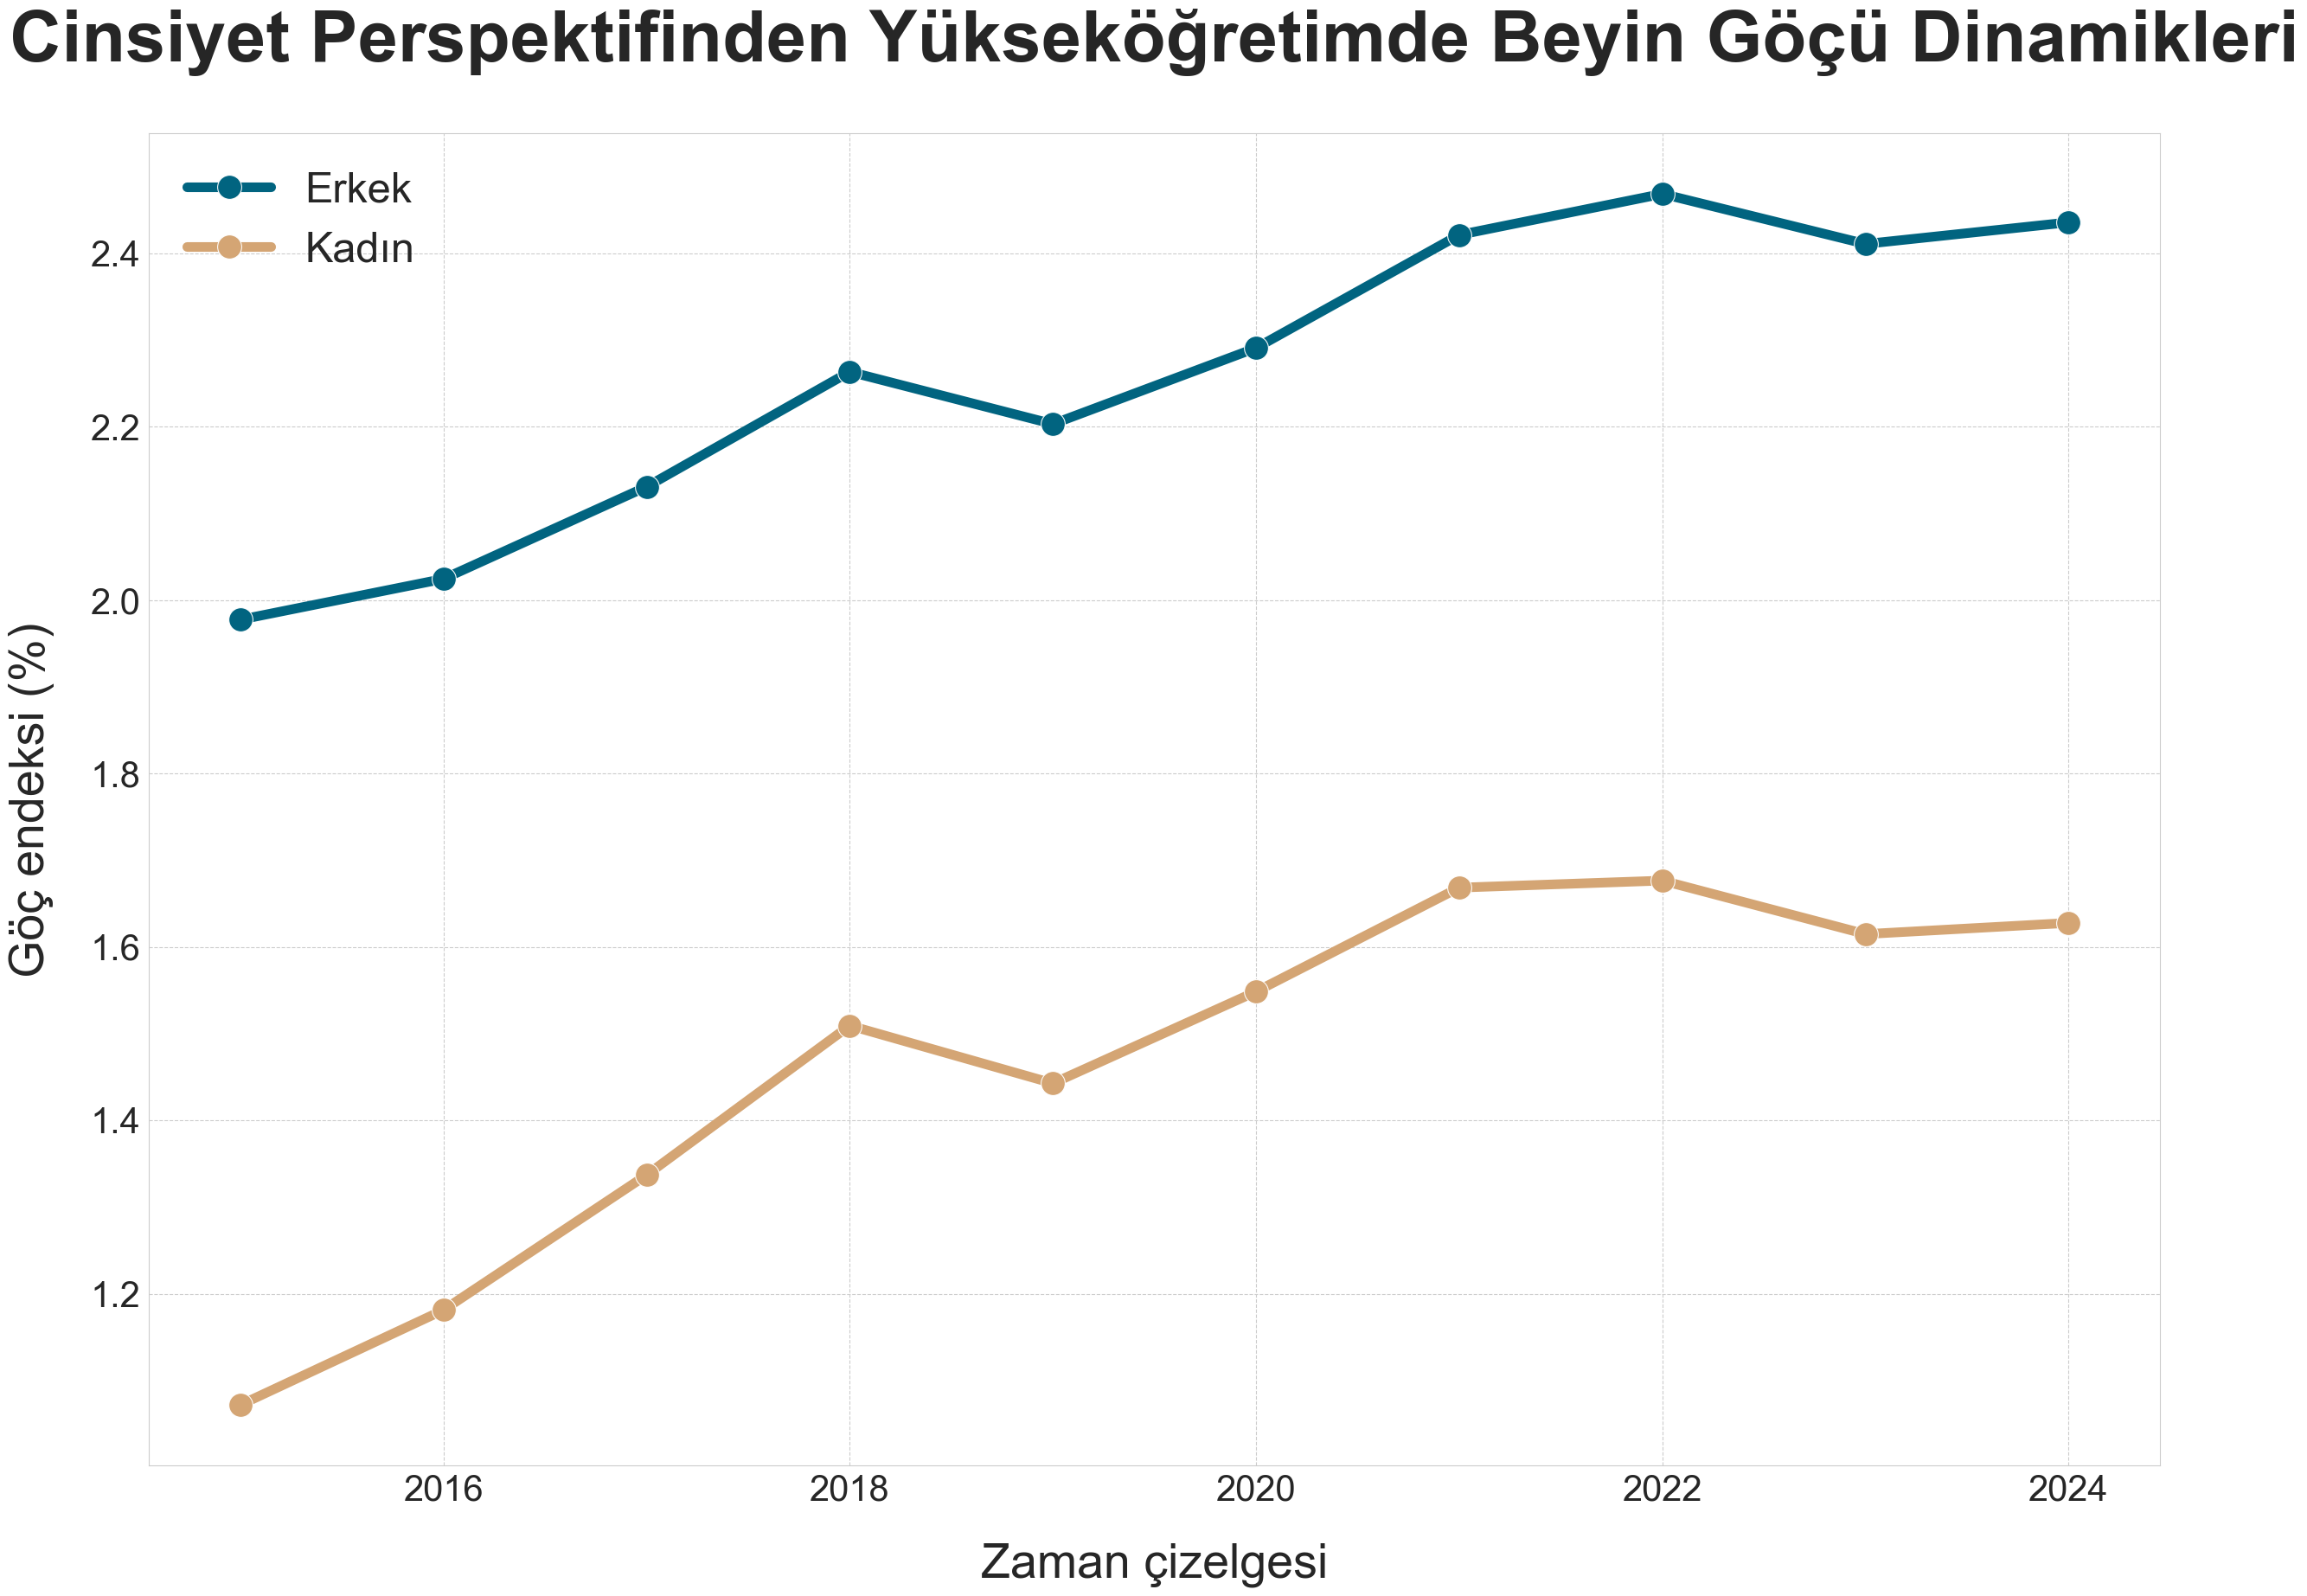

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Veriyi oku
df = pd.read_csv('Cinsiyete göre yükseköğretim mezunlarının beyin göçü oranı (TR,DF_YO_MEZUN_BEYIN_GOCU_ORAN,1.0).csv', sep=';')
df_clean = df[['Zaman (TIME_PERIOD)', 'Cinsiyet (DESC) (_T)', 'Gözlem']].copy()
df_clean.columns = ['Yil', 'Cinsiyet', 'Oran']
df_clean['Oran'] = df_clean['Oran'].str.replace(',', '.').astype(float)
df_plot = df_clean[df_clean['Cinsiyet'].isin(['Erkek', 'Kadın'])].copy()

# Grafik ayarları (60 ve 40 punto için devasa bir figür boyutu gerekiyor)
fig, ax = plt.subplots(figsize=(30, 20), facecolor='white')

# Çizim
sns.lineplot(data=df_plot, x='Yil', y='Oran', hue='Cinsiyet', 
             palette=["#016480", "#D4A574"], linewidth=8, marker='o', markersize=20, ax=ax)

# BAŞLIK: Bold, 60 Punto, Her Kelimenin İlk Harfi Büyük
ax.set_title('Cinsiyet Perspektifinden Yükseköğretimde Beyin Göçü Dinamikleri', 
             fontsize=60, fontweight='bold', pad=60)

# AÇIKLAMA: 40 Punto, Tümce düzeni
ax.set_xlabel('Zaman çizelgesi', fontsize=40, labelpad=30)
ax.set_ylabel('Göç endeksi (%)', fontsize=40, labelpad=30)

# Eksen değerleri puntosu
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.legend(fontsize=35, frameon=False)

# PNG OLARAK KAYDET
plt.savefig("istenen_grafik.png", dpi=300, bbox_inches='tight')
plt.show()

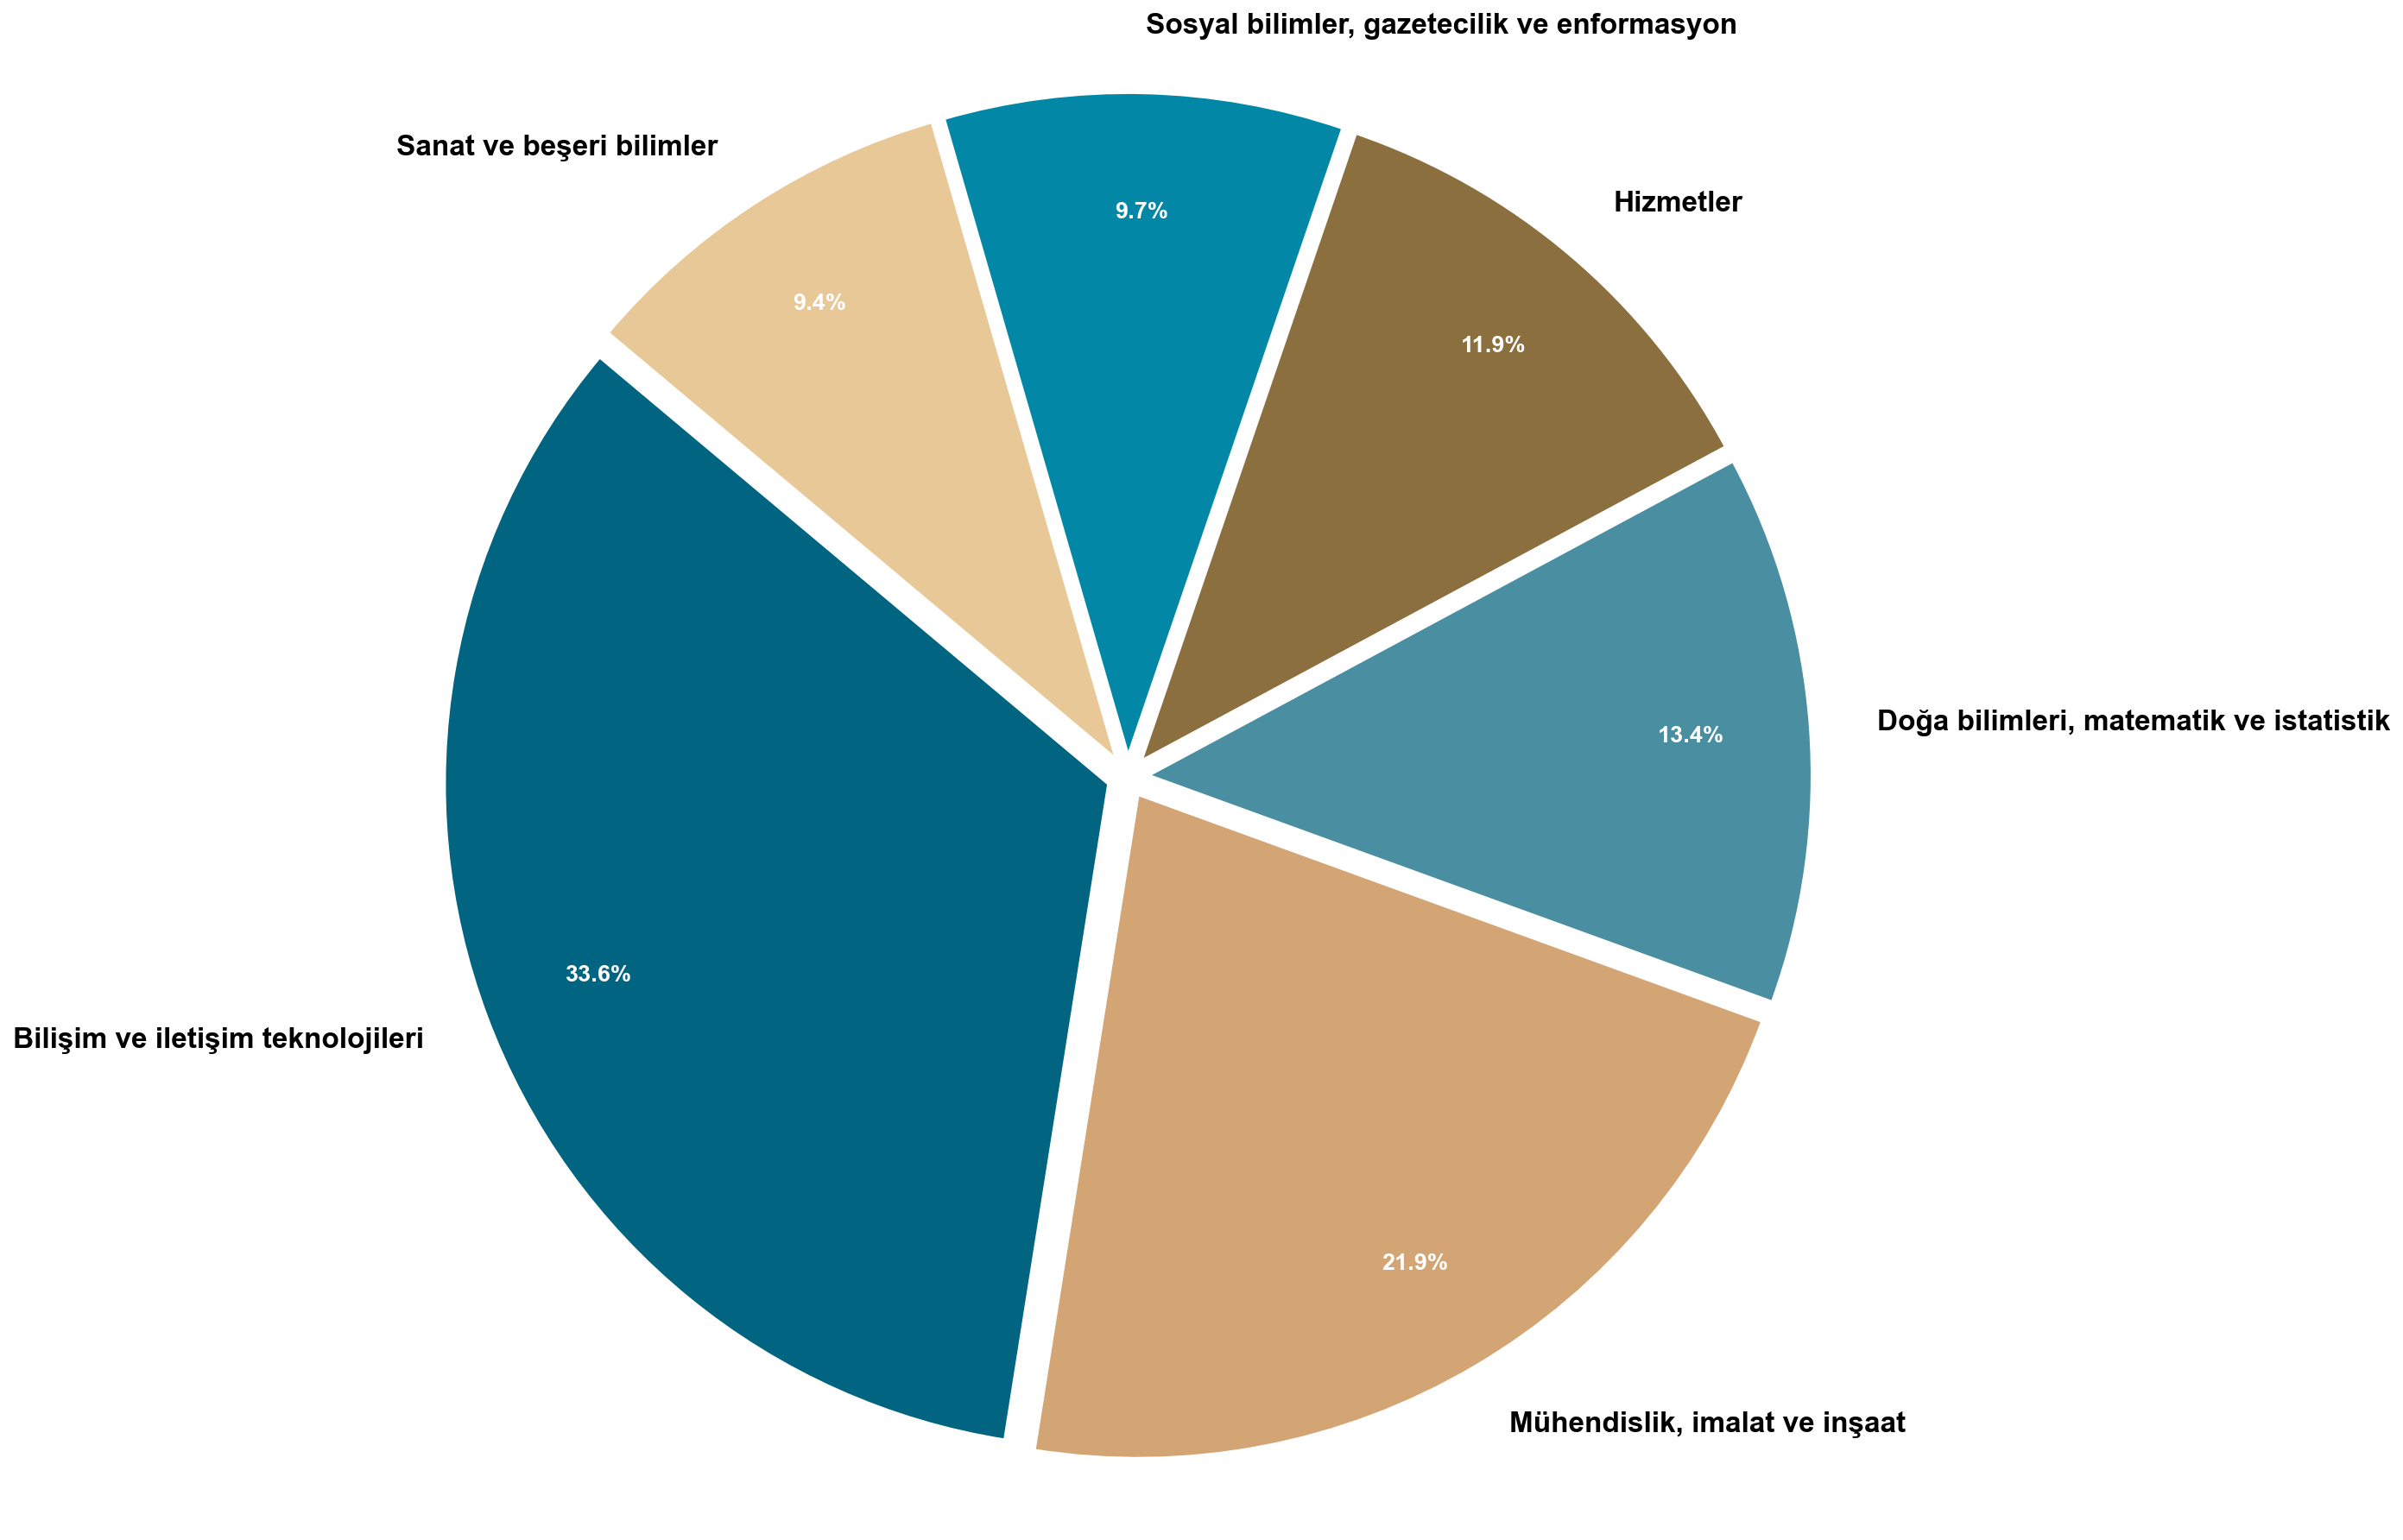

In [14]:
import pandas as pd
import matplotlib.pyplot as plt


file_path = 'Eğitim ve öğretim alanlarına göre yükseköğretim mezunlarının beyin göçü oranı (TR,DF_EGITIM_OGRETIM_ALAN,1.0).csv'
df = pd.read_csv(file_path, sep=';')
df.columns = df.columns.str.strip()


df['Gözlem'] = df['Gözlem'].str.replace(',', '.').astype(float)


FSMVÜ_PALET = ['#016480', '#D4A574', '#4A8FA1', '#8B6F3F', '#0288A6', '#E8C896']


df_plot = df[df['Zaman (TIME_PERIOD)'] == 2024].nlargest(len(FSMVÜ_PALET), 'Gözlem')


plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

fig, ax = plt.subplots(figsize=(16, 12), facecolor='white', dpi=150)


explode = [0.03] * len(df_plot) 

wedges, texts, autotexts = ax.pie(
    df_plot['Gözlem'], 
    labels=df_plot['Eğitim ve Öğretim Alanları (1)'],
    autopct='%1.1f%%',
    startangle=140,
    colors=FSMVÜ_PALET,
    pctdistance=0.82,
    explode=explode,
    
    textprops={'fontsize': 16, 'fontweight': 'black', 'color': '#000000'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)


for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('black')
    autotext.set_fontsize(13)

# Ekstra temizlik
ax.set_title("")
ax.axis('equal') 

plt.tight_layout()
plt.show()

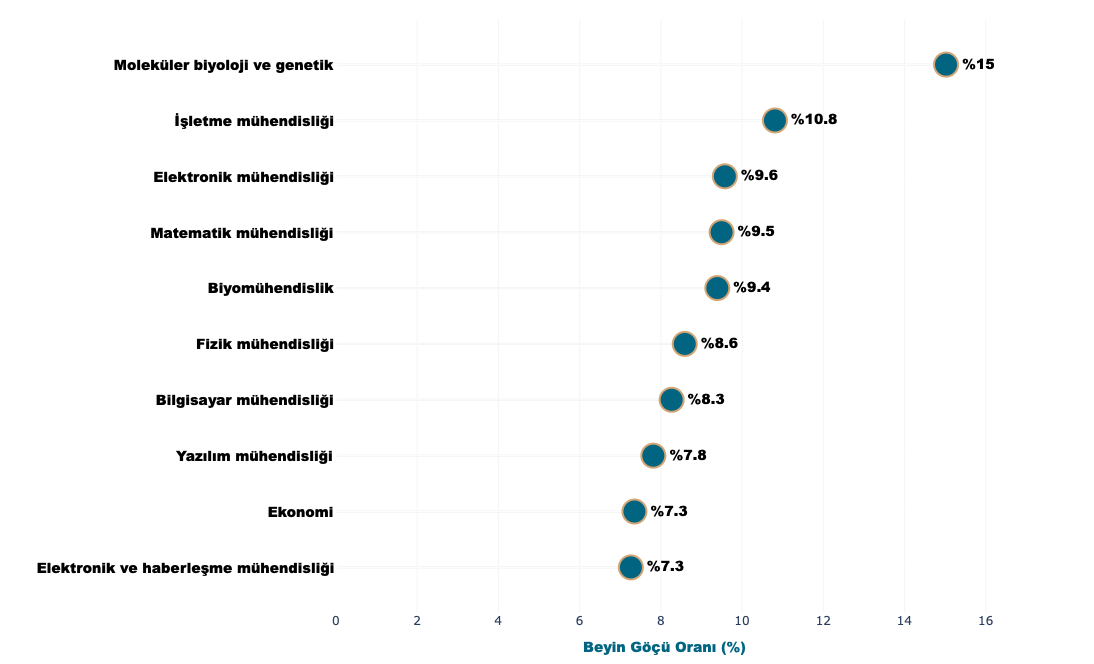

In [16]:
import pandas as pd
import plotly.graph_objects as go


file_name = 'Tamamladıkları bölüme göre yükseköğretim mezunlarının beyin göçü oranı (TR,DF_TAMAMLANAN_BOLUM_BGO,1.0).csv'
df = pd.read_csv(file_name, sep=';')


df['Gözlem'] = df['Gözlem'].str.replace(',', '.')
df['Gözlem'] = pd.to_numeric(df['Gözlem'], errors='coerce')


df_2024 = df[df['Zaman (TIME_PERIOD)'] == 2024].dropna(subset=['Gözlem'])
df_top10 = df_2024.sort_values(by='Gözlem', ascending=True).tail(10)


FSMVÜ_PETROL = '#016480'
FSMVÜ_ALTIN = '#D4A574'


fig = go.Figure()


for i, row in df_top10.iterrows():
    fig.add_shape(
        type='line', layer='below',
        x0=0, y0=row['Bölüm'], x1=row['Gözlem'], y1=row['Bölüm'],
        line=dict(color='#EEEEEE', width=2)
    )


fig.add_trace(go.Scatter(
    x=df_top10['Gözlem'],
    y=df_top10['Bölüm'],
    mode='markers+text',
    marker=dict(
        color=FSMVÜ_PETROL, 
        size=24, # Daire boyutu
        symbol='circle',
        line=dict(color=FSMVÜ_ALTIN, width=2)
    ),
    text=df_top10['Gözlem'].apply(lambda x: f"%{x:.1f}"),
    textposition="middle right",
    textfont=dict(family="Arial Black", size=14, color="black"),
    name="Beyin Göçü"
))


fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=650,
    margin=dict(l=250, r=100, t=20, b=50),
    xaxis=dict(
        showgrid=True, gridcolor='#F5F5F5', 
        title="Beyin Göçü Oranı (%)",
        title_font=dict(family="Arial Black", size=14, color=FSMVÜ_PETROL)
    ),
    yaxis=dict(
        tickfont=dict(family="Arial Black", size=14, color="black"),
        title=""
    ),
    showlegend=False
)

fig.show()

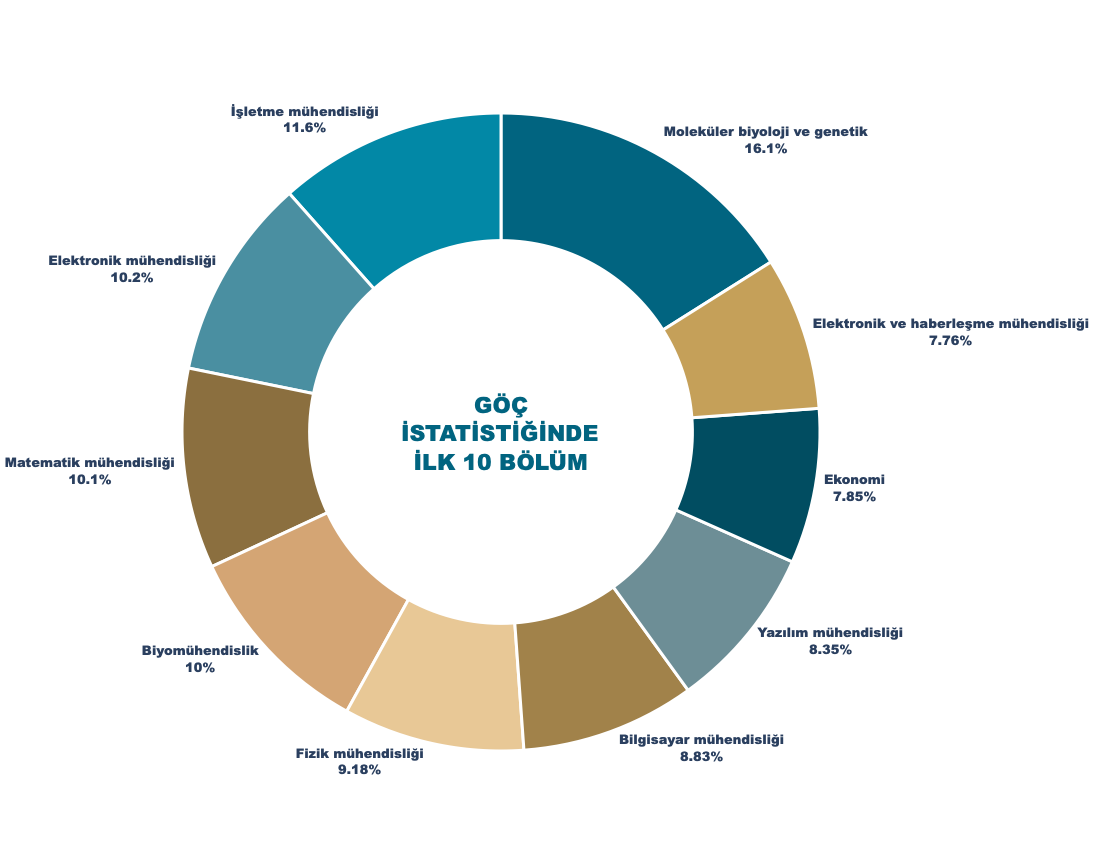

In [60]:
import pandas as pd
import plotly.express as px

# 1. VERİ OKUMA VE HAZIRLIK
file_name = 'Tamamladıkları bölüme göre yükseköğretim mezunlarının beyin göçü oranı (TR,DF_TAMAMLANAN_BOLUM_BGO,1.0).csv'
df = pd.read_csv(file_name, sep=';')

# Veriyi temizle ve sayıya çevir
df['Gözlem'] = df['Gözlem'].str.replace(',', '.')
df['Gözlem'] = pd.to_numeric(df['Gözlem'], errors='coerce')

# 2024 Yılı - Beyin Göçü Oranı En Yüksek İlk 10 Bölüm
df_2024 = df[df['Zaman (TIME_PERIOD)'] == 2024].dropna(subset=['Gözlem'])
df_top10 = df_2024.sort_values(by='Gözlem', ascending=False).head(10)

# 2. FSMVÜ KURUMSAL RENK PALETİ
# Petrol Mavisinden Altına doğru prestijli bir geçiş
FSMVÜ_PALET = ['#016480', '#0288A6', '#4A8FA1', '#8B6F3F', '#D4A574', 
               '#E8C896', '#A1824A', '#6D8E96', '#014D61', '#C5A059']

# 3. DONUT CHART (HALKA GRAFİK) TASARIMI
fig = px.pie(
    df_top10, 
    values='Gözlem', 
    names='Bölüm',
    color_discrete_sequence=FSMVÜ_PALET,
    hole=0.6, # Merkeze başlık yazmak için geniş bir boşluk
    template="plotly_white"
)

# 4. GÖRSEL DOKUNUŞLAR VE BAŞLIK YERLEŞİMİ
fig.update_traces(
    textinfo='percent+label',
    textposition='outside', # İsimlerin karışmaması için dışarıya alıyoruz
    marker=dict(line=dict(color='#FFFFFF', width=3)), # Dilim ayrımı için beyaz jilet çizgiler
    textfont=dict(family="Arial Black", size=13)
)

fig.update_layout(
    showlegend=False,
    margin=dict(t=100, b=100, l=150, r=150),
    height=850,
    # MERKEZDEKİ ESTETİK BAŞLIK
    annotations=[dict(
        text='<b>GÖÇ<br>İSTATİSTİĞİNDE<br>İLK 10 BÖLÜM</b>', 
        x=0.5, y=0.5, 
        font_size=22, 
        font_family="Arial Black", 
        font_color="#016480",
        showarrow=False
    )]
)

fig.show()

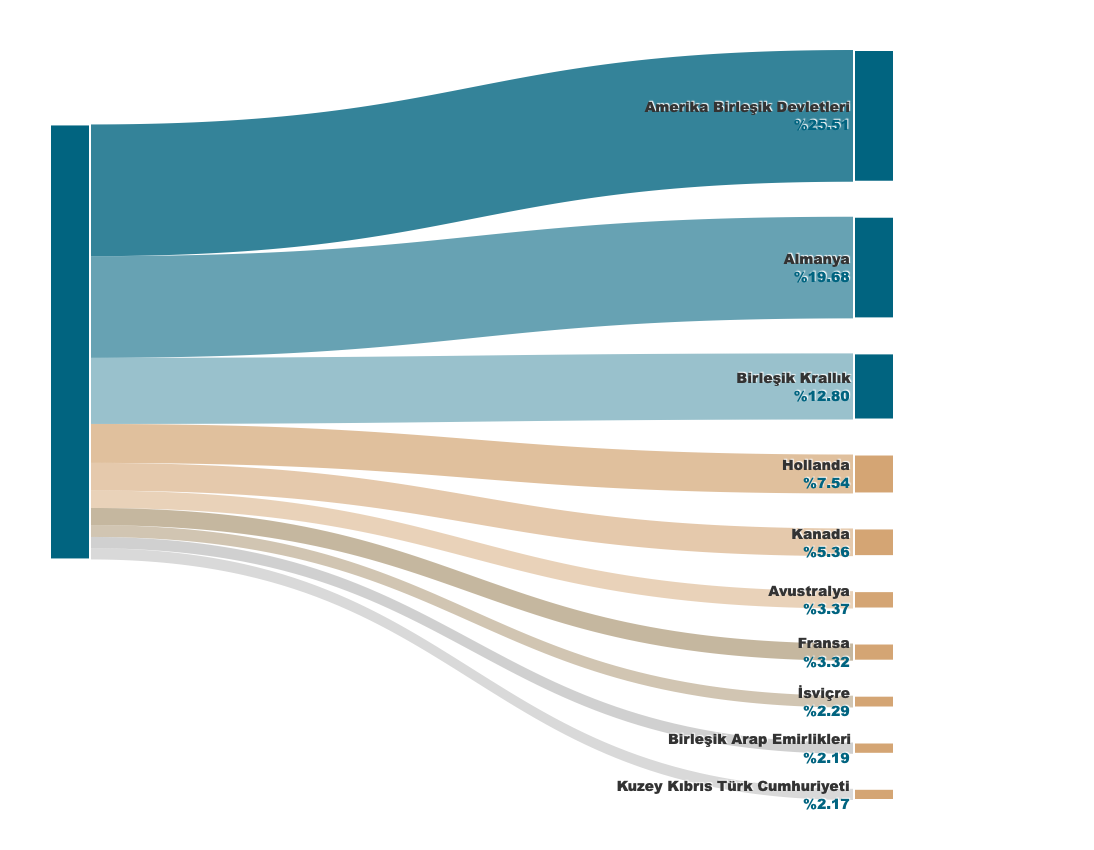

In [81]:
import pandas as pd
import plotly.graph_objects as go

# 1. VERİ OKUMA VE ON YILLIK ANALİZ
file_name = 'Yükseköğretim mezunlarının göç ettikleri ülkelere göre dağılımı (TR,DF_GOC_ULKE_DAGILIM,1.0).csv'
df = pd.read_csv(file_name, sep=';')

# Veriyi temizle ve sayıya çevir
df['Gözlem'] = pd.to_numeric(df['Gözlem'].str.replace(',', '.'), errors='coerce')

# "Diğer" kategorisini ve 0 olanları ele, 2015-2024 arasını kapsa
df_clean = df[(df['Ülke'] != 'Diğer') & (df['Gözlem'] > 0)].copy()

# TÜM YILLARI HESAPLA: Ülke bazında 10 yıllık toplam/ortalama ağırlığı bul
# Burada 'Gözlem' değerlerini toplayıp toplam içindeki gerçek paylarını buluyoruz
total_stats = df_clean.groupby('Ülke')['Gözlem'].sum().reset_index()
total_sum = total_stats['Gözlem'].sum()
total_stats['Oran'] = (total_stats['Gözlem'] / total_sum) * 100

# En yüksek 10 ülkeyi seç
df_top10 = total_stats.sort_values(by='Oran', ascending=False).head(10)

# 2. FSMVÜ PREMIUM RENK PALETİ
PETROL = '#016480'
ALTIN  = '#D4A574'
BRONZ  = '#8B6F3F'
GUMUS  = '#A1A1A1'

# 3. SANKEY YAPILANDIRMASI
# Türkiye düğümü (0) gizli kalacak şekilde boşluk bırakıldı
label_list = [" "] + [f"<b>{u}</b><br><span style='color:{PETROL}'>%{v:.2f}</span>" 
                      for u, v in zip(df_top10['Ülke'], df_top10['Oran'])]

source = [0] * 10
target = list(range(1, 11))
values = df_top10['Oran'].tolist()

# Renk Geçişleri (İlk 3 Koyu Petrol, diğerleri Altın ve Bronz gradyan)
link_colors = [
    'rgba(1, 100, 128, 0.8)', 'rgba(1, 100, 128, 0.6)', 'rgba(1, 100, 128, 0.4)', 
    'rgba(212, 165, 116, 0.7)', 'rgba(212, 165, 116, 0.6)', 'rgba(212, 165, 116, 0.5)',
    'rgba(139, 111, 63, 0.5)', 'rgba(139, 111, 63, 0.4)',
    'rgba(161, 161, 161, 0.5)', 'rgba(161, 161, 161, 0.4)'
]

# 4. GRAFİĞİ OLUŞTURMA
fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 35,
      thickness = 40,
      line = dict(color = "white", width = 2),
      label = label_list,
      color = [PETROL if i == 0 else (PETROL if i <= 3 else ALTIN) for i in range(11)],
    ),
    link = dict(
      source = source,
      target = target,
      value = values,
      color = link_colors,
      hovertemplate = '<b>%{target.label}</b><extra></extra>'
    )
)])

# 5. LAYOUT AYARLARI
fig.update_layout(
    font=dict(size = 14, family="Segoe UI, Arial Black", color="#333"),
    height=850,
    paper_bgcolor='white',
    plot_bgcolor='white',
    margin=dict(t=50, b=50, l=50, r=200) # Oranlar için sağda geniş pay
)

fig.show()

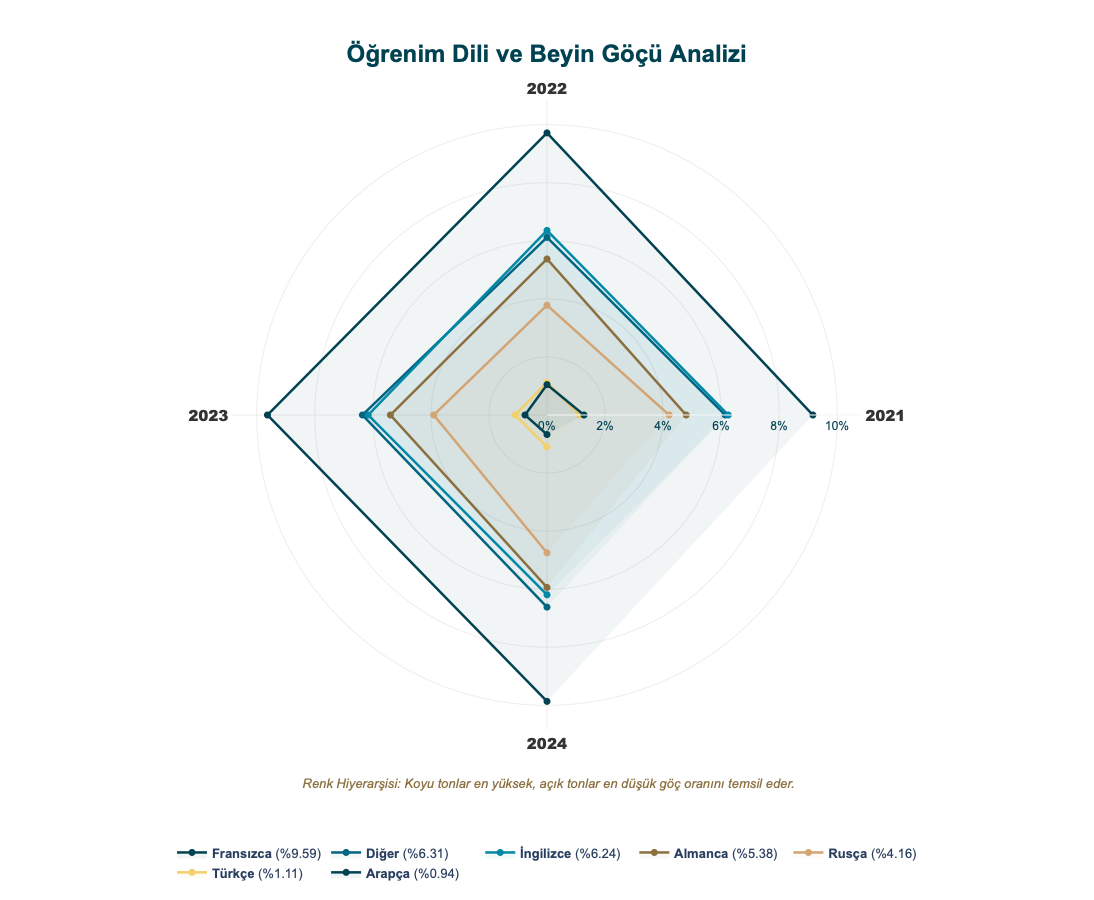

In [10]:
import pandas as pd
import plotly.graph_objects as go

# 1. VERİ OKUMA VE HAZIRLIK
file_name = 'Yükseköğretim öğrenim diline göre beyin göçü oranı (TR,DF_YO_OGRENIM_DIL,1.0).csv'
df = pd.read_csv(file_name, sep=';')

# Sayısal dönüşümler
df['Gözlem'] = pd.to_numeric(df['Gözlem'].str.replace(',', '.'), errors='coerce')
df['Zaman (TIME_PERIOD)'] = pd.to_numeric(df['Zaman (TIME_PERIOD)'], errors='coerce')

# Boşlukları doldurmak için pivot tablo
df_pivot = df.pivot_table(index='Zaman (TIME_PERIOD)', 
                          columns='Öğrenim Dili', 
                          values='Gözlem', 
                          aggfunc='mean').fillna(0)

# 2. STRATEJİK RENK SIRALAMASI VE GEÇİŞİ (Zarif Tonlar)
avg_ranks = df_pivot.mean().sort_values(ascending=False)
sorted_languages = avg_ranks.index.tolist()

FSM_GRADIENT = ['#014252', '#016480', '#0288A6', '#8B6F3F', '#D4A574', '#F2D06B']

# 3. RADAR GRAFİĞİ OLUŞTURMA
fig = go.Figure()
yıllar = df_pivot.index.astype(str)

for i, dil in enumerate(sorted_languages):
    color = FSM_GRADIENT[i % len(FSM_GRADIENT)]
    avg_val = avg_ranks[dil]
    rgb = tuple(int(color[1:][j:j+2], 16) for j in (0, 2, 4))
    
    fig.add_trace(go.Scatterpolar(
        r=df_pivot[dil].values,
        theta=yıllar,
        fill='toself', 
        fillcolor=f"rgba({rgb[0]}, {rgb[1]}, {rgb[2]}, 0.05)", # Ultra şeffaf (Zarif geçiş)
        name=f"<b>{dil}</b> <span style='font-size:13px;'>(%{avg_val:.2f})</span>",
        line=dict(color=color, width=2.5), # İnce ve jilet gibi hatlar
        marker=dict(size=7, symbol='circle'), # Kibar noktalar
        hoverinfo="name+r"
    ))

# 4. FERAH AMA ZARİF TASARIM AYARLARI
fig.update_layout(
    height=900, # Tuval büyük kalsın
    width=1000,
    title={
        'text': "<b>Öğrenim Dili ve Beyin Göçü Analizi</b>",
        'y': 0.95, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top',
        'font': {'size': 24, 'family': 'Arial', 'color': '#014252'}
    },
    annotations=[
        dict(
            text="<i> Renk Hiyerarşisi: Koyu tonlar en yüksek, açık tonlar en düşük göç oranını temsil eder.</i>",
            showarrow=False, xref="paper", yref="paper",
            x=0.5, y=-0.1,
            font=dict(size=13, color="#8B6F3F", family="Arial"),
            xanchor="center"
        )
    ],
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, df['Gözlem'].max() * 1.1],
            gridcolor="#EEEEEE", # Çok hafif ızgara
            gridwidth=1,
            tickfont=dict(size=12, family="Arial", color="#014252"),
            ticksuffix="%"
        ),
        angularaxis=dict(
            gridcolor="#EEEEEE",
            gridwidth=1,
            tickfont=dict(size=15, family="Arial Black", color="#333") # Yıllar net ama kaba değil
        ),
        bgcolor="white"
    ),
    margin=dict(t=100, b=150, l=100, r=100),
    legend=dict(
        orientation="h",
        yanchor="bottom", y=-0.25,
        xanchor="center", x=0.5,
        font=dict(size=13, family="Arial"),
        bgcolor="rgba(255,255,255,0)"
    )
)

fig.show()

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning:

Glyph 128204 (\N{PUSHPIN}) missing from font(s) Arial.



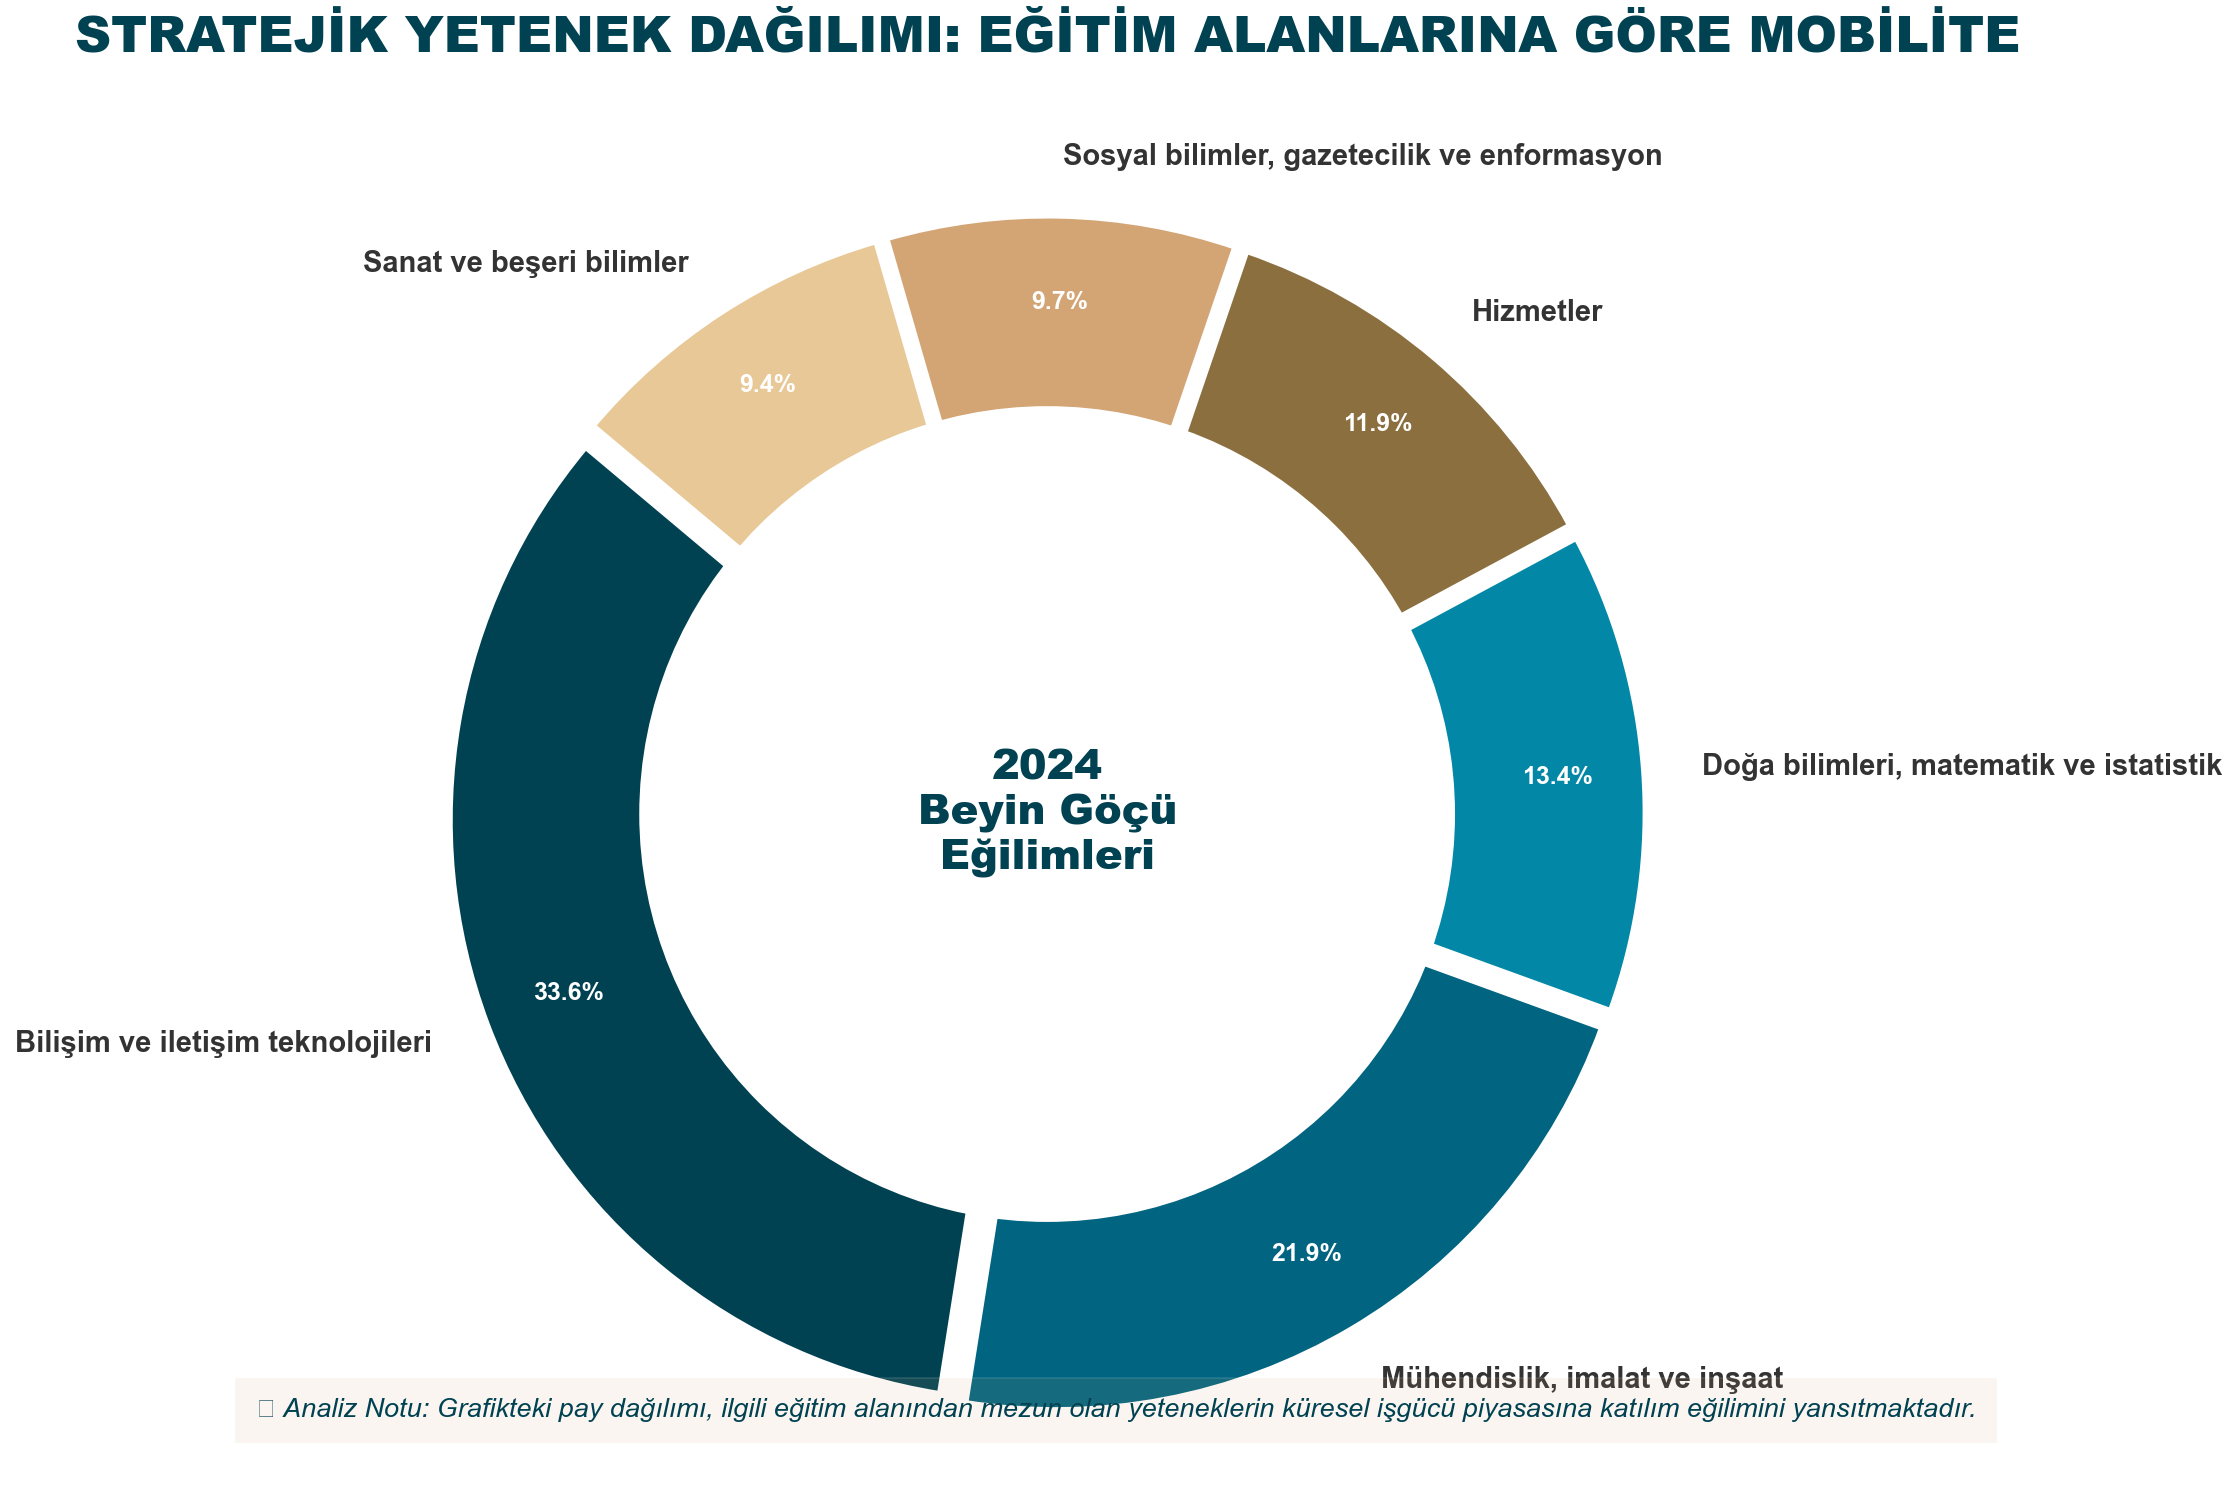

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. VERİ OKUMA VE HAZIRLIK
file_path = 'Eğitim ve öğretim alanlarına göre yükseköğretim mezunlarının beyin göçü oranı (TR,DF_EGITIM_OGRETIM_ALAN,1.0).csv'
df = pd.read_csv(file_path, sep=';')
df.columns = df.columns.str.strip()

# Sayısal dönüşüm
df['Gözlem'] = df['Gözlem'].str.replace(',', '.').astype(float)

# FSMVÜ Kurumsal Renk Paleti (Geçişli ve Zarif)
FSMVÜ_PALET = ['#014252', '#016480', '#0288A6', '#8B6F3F', '#D4A574', '#E8C896']

# 2024 Yılı Verisini Filtrele ve En Yüksek Alanları Seç
df_plot = df[df['Zaman (TIME_PERIOD)'] == 2024].nlargest(len(FSMVÜ_PALET), 'Gözlem')

# 2. GRAFİK KURGUSU
plt.rcParams['font.family'] = 'sans-serif'
fig, ax = plt.subplots(figsize=(14, 10), facecolor='white', dpi=150)

# Donut Chart için explode (dilimlerin ayrılması)
explode = [0.03] * len(df_plot)

# Donut Chart Çizimi
wedges, texts, autotexts = ax.pie(
    df_plot['Gözlem'], 
    labels=df_plot['Eğitim ve Öğretim Alanları (1)'],
    autopct='%1.1f%%',
    startangle=140,
    colors=FSMVÜ_PALET,
    pctdistance=0.85,
    explode=explode,
    textprops={'fontsize': 14, 'fontweight': 'bold', 'color': '#333333'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 3} # Beyaz hatlar jilet gibi net
)

# Ortadaki Boşluğu Oluşturma (Donut Efekti)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Merkeze "Anlamlı" Bir Vurgu Ekleme
ax.text(0, 0, '2024\nBeyin Göçü\nEğilimleri', ha='center', va='center', 
        fontsize=20, fontweight='black', color='#014252', family='Arial Black')

# Yüzdelik yazılarını beyaza çekme
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('black')
    autotext.set_fontsize(12)

# 3. ESTETİK BAŞLIK VE ANALİTİK NOT
plt.title("STRATEJİK YETENEK DAĞILIMI: EĞİTİM ALANLARINA GÖRE MOBİLİTE", 
          pad=50, fontsize=24, fontweight='black', color='#014252', family='Arial Black')

# Alt kısımdaki analitik not
plt.figtext(0.5, 0.05, 
            "📌 Analiz Notu: Grafikteki pay dağılımı, ilgili eğitim alanından mezun olan yeteneklerin küresel işgücü piyasasına katılım eğilimini yansıtmaktadır.", 
            ha="center", fontsize=13, bbox={"facecolor":"#D4A574", "alpha":0.1, "pad":10}, 
            color="#014252", style='italic')

ax.axis('equal')  
plt.tight_layout()
plt.show()

In [18]:
import pandas as pd
import plotly.graph_objects as go

# 1. VERİ OKUMA VE HAZIRLIK
file_name = 'Tamamladıkları bölüme göre yükseköğretim mezunlarının beyin göçü oranı (TR,DF_TAMAMLANAN_BOLUM_BGO,1.0).csv'
df = pd.read_csv(file_name, sep=';')

# Sayısal dönüşüm
df['Gözlem'] = df['Gözlem'].str.replace(',', '.')
df['Gözlem'] = pd.to_numeric(df['Gözlem'], errors='coerce')

# 2024 Yılı - En Yüksek 10 Bölüm (Küçükten büyüğe sıralıyoruz ki grafikte yukarı doğru yükselsin)
df_2024 = df[df['Zaman (TIME_PERIOD)'] == 2024].dropna(subset=['Gözlem'])
df_top10 = df_2024.sort_values(by='Gözlem', ascending=True).tail(10)

# 2. FSMVÜ KURUMSAL RENK PALETİ (Hiyerarşik Geçiş)
FSMVÜ_PALET = [
    '#E8C896', '#D4A574', '#A1824A', '#8B6F3F', '#6D8E96', 
    '#4A8FA1', '#0288A6', '#016480', '#014D61', '#014252'
]

# 3. LOLLIPOP GRAFİK OLUŞTURMA
fig = go.Figure()

# Her bir satır (bölüm) için döngü kurarak renkleri ve çizgileri özelleştiriyoruz
for i, (index, row) in enumerate(df_top10.iterrows()):
    color = FSMVÜ_PALET[i % len(FSMVÜ_PALET)]
    
    # Yatay Çizgi (Sap kısmı)
    fig.add_shape(
        type='line',
        x0=0, y0=row['Bölüm'],
        x1=row['Gözlem'], y1=row['Bölüm'],
        line=dict(color=color, width=3, dash="dot"), # Noktalı ve renkli şık çizgiler
    )
    
    # Nokta (Baş kısmı) ve Değer Yazısı
    fig.add_trace(go.Scatter(
        x=[row['Gözlem']],
        y=[row['Bölüm']],
        mode='markers+text',
        marker=dict(
            color=color, 
            size=26, 
            line=dict(color='white', width=3), # Etrafında beyaz halka ile parlatma
            shadow=dict(color='black', blur=10) # Hafif derinlik
        ),
        text=[f"<b>%{row['Gözlem']:.1f}</b>"],
        textposition="middle right",
        textfont=dict(family="Arial Black", size=15, color=color),
        showlegend=False
    ))

# 4. ESTETİK TASARIM VE KURUMSAL NOT
fig.update_layout(
    title={
        'text': "<b>BEYİN GÖÇÜNÜN ZİRVESİNDEKİ LİSANS BÖLÜMLERİ</b><br><span style='font-size:14px; color:gray;'>2024 Yılı Mezuniyet Alanlarına Göre Göç Yoğunluğu</span>",
        'y': 0.95, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top',
        'font': {'size': 26, 'family': 'Arial Black', 'color': '#014252'}
    },
    annotations=[
        dict(
            text="📌 <b>Analitik Not:</b> Rakamlar, ilgili bölüm mezunlarının yurt dışı işgücü piyasasına katılım oranını temsil eder. Koyu tonlar en yüksek mobiliteyi simgeler.",
            showarrow=False, xref="paper", yref="paper",
            x=0.5, y=-0.15,
            font=dict(size=14, color="#014252", family="Arial"),
            xanchor="center",

_IncompleteInputError: incomplete input (930883516.py, line 67)

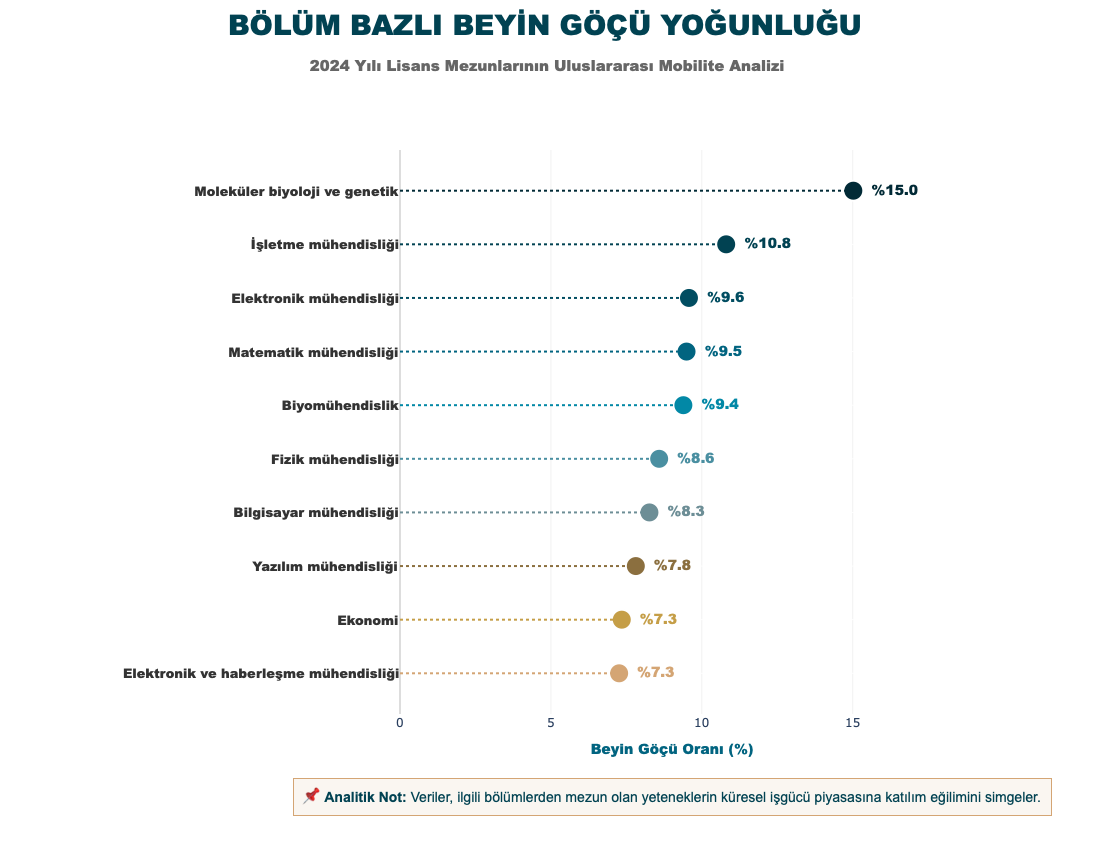

In [21]:
import pandas as pd
import plotly.graph_objects as go

# 1. VERİ OKUMA VE HAZIRLIK
file_name = 'Tamamladıkları bölüme göre yükseköğretim mezunlarının beyin göçü oranı (TR,DF_TAMAMLANAN_BOLUM_BGO,1.0).csv'
df = pd.read_csv(file_name, sep=';')

# Sayısal dönüşüm
df['Gözlem'] = df['Gözlem'].str.replace(',', '.')
df['Gözlem'] = pd.to_numeric(df['Gözlem'], errors='coerce')

# 2024 Yılı - En Yüksek 10 Bölüm
df_2024 = df[df['Zaman (TIME_PERIOD)'] == 2024].dropna(subset=['Gözlem'])
df_top10 = df_2024.sort_values(by='Gözlem', ascending=True).tail(10)

# 2. FSMVÜ KURUMSAL RENK PALETİ (Premium Geçiş)
FSMVÜ_PALET = [
    '#D4A574', '#C59E47', '#8B6F3F', '#6D8E96', '#4A8FA1', 
    '#0288A6', '#016480', '#014D61', '#014252', '#012A36'
]

# 3. LOLLIPOP GRAFİK OLUŞTURMA
fig = go.Figure()

for i, (index, row) in enumerate(df_top10.iterrows()):
    color = FSMVÜ_PALET[i % len(FSMVÜ_PALET)]
    
    # Yatay Çizgi (İnce ve Keskin)
    fig.add_shape(
        type='line', x0=0, y0=row['Bölüm'], x1=row['Gözlem'], y1=row['Bölüm'],
        line=dict(color=color, width=2, dash="dot")
    )
    
    # Nokta ve Değer Yazısı
    fig.add_trace(go.Scatter(
        x=[row['Gözlem']],
        y=[row['Bölüm']],
        mode='markers+text',
        marker=dict(
            color=color, size=20, 
            line=dict(color='white', width=2)
        ),
        text=[f" %{row['Gözlem']:.1f}"],
        textposition="middle right",
        textfont=dict(family="Arial Black", size=14, color=color),
        showlegend=False
    ))

# 4. TASARIM VE BAŞLIK AYARLARI
fig.update_layout(
    height=850,
    width=1200,
    plot_bgcolor='white',
    paper_bgcolor='white',
    # Sol tarafın kesilmemesi için geniş marjin
    margin=dict(l=400, r=150, t=150, b=150),
    
    # ESTETİK BAŞLIK DÜZENİ
    title={
        'text': "<b>BÖLÜM BAZLI BEYİN GÖÇÜ YOĞUNLUĞU</b><br><span style='font-size:15px; color:#666;'>2024 Yılı Lisans Mezunlarının Uluslararası Mobilite Analizi</span>",
        'y': 0.96, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top',
        'font': {'size': 28, 'family': 'Arial Black', 'color': '#014252'}
    },
    
    # ANLAMLI ANALİTİK NOT
    annotations=[
        dict(
            text="📌 <b>Analitik Not:</b> Veriler, ilgili bölümlerden mezun olan yeteneklerin küresel işgücü piyasasına katılım eğilimini simgeler.",
            showarrow=False, xref="paper", yref="paper",
            x=0.5, y=-0.18,
            font=dict(size=14, color="#014252", family="Arial"),
            xanchor="center",
            bgcolor="rgba(212, 165, 116, 0.1)",
            bordercolor="#D4A574", borderwidth=1, borderpad=10
        )
    ],
    
    xaxis=dict(
        showgrid=True, gridcolor='#F2F2F2',
        title="Beyin Göçü Oranı (%)",
        title_font=dict(family="Arial Black", size=14, color="#016480"),
        range=[0, df_top10['Gözlem'].max() * 1.2],
        zeroline=True, zerolinecolor='#DDD'
    ),
    
    yaxis=dict(
        tickfont=dict(family="Arial Black", size=13, color="#333"),
        title="",
        automargin=False
    )
)

fig.show()

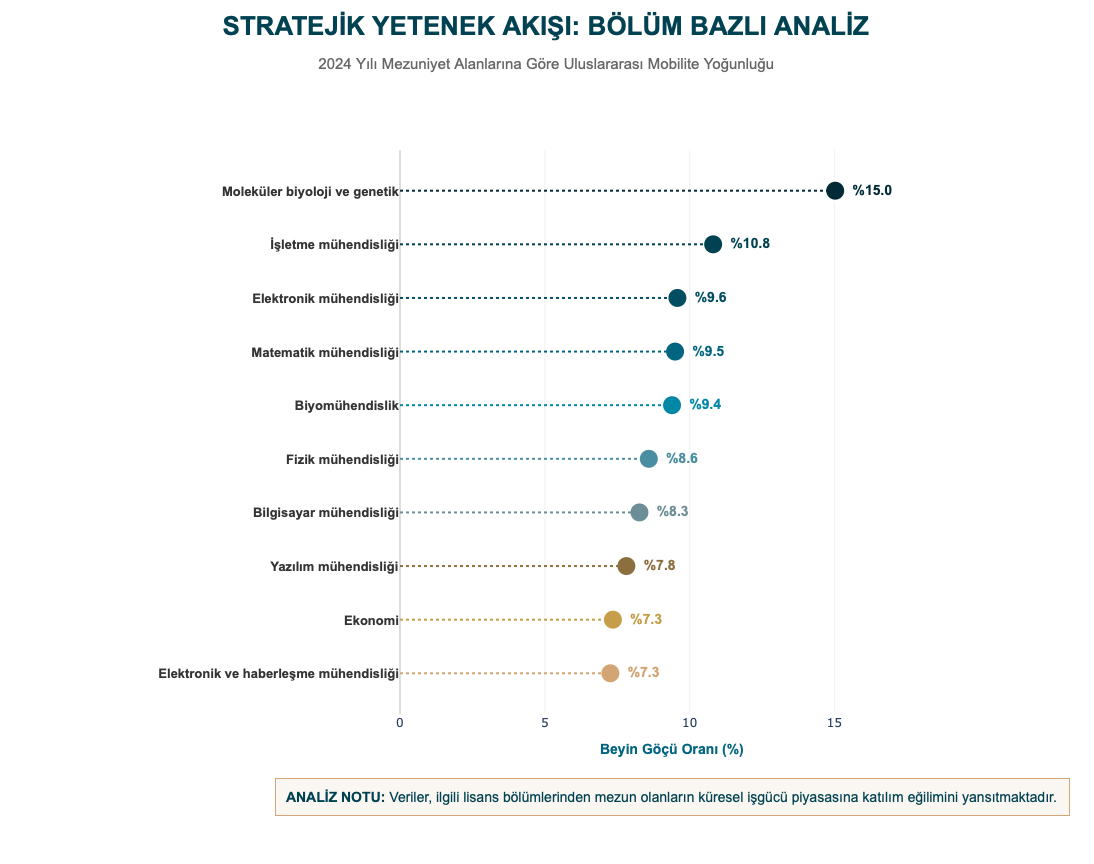

In [23]:
import pandas as pd
import plotly.graph_objects as go

# 1. VERİ OKUMA VE HAZIRLIK
file_name = 'Tamamladıkları bölüme göre yükseköğretim mezunlarının beyin göçü oranı (TR,DF_TAMAMLANAN_BOLUM_BGO,1.0).csv'
df = pd.read_csv(file_name, sep=';')

# Sayısal dönüşüm
df['Gözlem'] = df['Gözlem'].str.replace(',', '.')
df['Gözlem'] = pd.to_numeric(df['Gözlem'], errors='coerce')

# 2024 Yılı - En Yüksek 10 Bölüm
df_2024 = df[df['Zaman (TIME_PERIOD)'] == 2024].dropna(subset=['Gözlem'])
df_top10 = df_2024.sort_values(by='Gözlem', ascending=True).tail(10)

# 2. FSMVÜ KURUMSAL RENK PALETİ
FSMVÜ_PALET = [
    '#D4A574', '#C59E47', '#8B6F3F', '#6D8E96', '#4A8FA1', 
    '#0288A6', '#016480', '#014D61', '#014252', '#012A36'
]

# 3. LOLLIPOP GRAFİK OLUŞTURMA
fig = go.Figure()

for i, (index, row) in enumerate(df_top10.iterrows()):
    color = FSMVÜ_PALET[i % len(FSMVÜ_PALET)]
    
    # Yatay Çizgi
    fig.add_shape(
        type='line', x0=0, y0=row['Bölüm'], x1=row['Gözlem'], y1=row['Bölüm'],
        line=dict(color=color, width=2, dash="dot")
    )
    
    # Nokta ve Değer Yazısı
    fig.add_trace(go.Scatter(
        x=[row['Gözlem']],
        y=[row['Bölüm']],
        mode='markers+text',
        marker=dict(
            color=color, size=20, 
            line=dict(color='white', width=2)
        ),
        text=[f" %{row['Gözlem']:.1f}"],
        textposition="middle right",
        # HATA BURADAYDI: fontweight yerine weight kullanıldı
        textfont=dict(family="Arial", size=14, color=color, weight='bold'),
        showlegend=False
    ))

# 4. TASARIM VE KURUMSAL HİZALAMA
fig.update_layout(
    height=850,
    width=1200,
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=400, r=150, t=150, b=150),
    
    title={
        'text': "<b>STRATEJİK YETENEK AKIŞI: BÖLÜM BAZLI ANALİZ</b><br><span style='font-size:15px; color:#666;'>2024 Yılı Mezuniyet Alanlarına Göre Uluslararası Mobilite Yoğunluğu</span>",
        'y': 0.96, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top',
        'font': {'size': 26, 'family': 'Arial', 'color': '#014252'}
    },
    
    annotations=[
        dict(
            text="<b>ANALİZ NOTU:</b> Veriler, ilgili lisans bölümlerinden mezun olanların küresel işgücü piyasasına katılım eğilimini yansıtmaktadır.",
            showarrow=False, xref="paper", yref="paper",
            x=0.5, y=-0.18,
            font=dict(size=14, color="#014252", family="Arial"),
            xanchor="center",
            bgcolor="rgba(212, 165, 116, 0.1)",
            bordercolor="#D4A574", borderwidth=1, borderpad=10
        )
    ],
    
    xaxis=dict(
        showgrid=True, gridcolor='#F2F2F2',
        title="Beyin Göçü Oranı (%)",
        title_font=dict(family="Arial", size=14, color="#016480", weight='bold'),
        range=[0, df_top10['Gözlem'].max() * 1.25],
        zeroline=True, zerolinecolor='#DDD'
    ),
    
    yaxis=dict(
        tickfont=dict(family="Arial", size=13, color="#333", weight='bold'),
        title="",
        automargin=False
    )
)

fig.show()


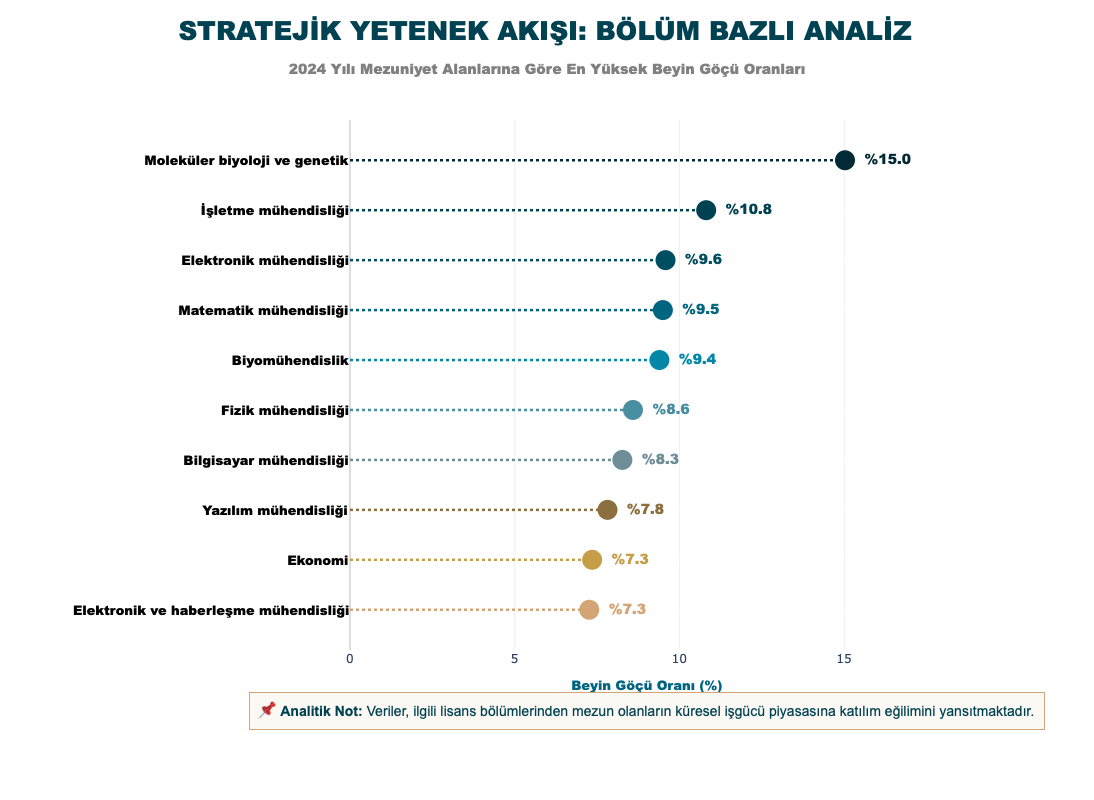

In [26]:
import pandas as pd
import plotly.graph_objects as go

# 1. VERİ OKUMA VE HAZIRLIK
file_name = 'Tamamladıkları bölüme göre yükseköğretim mezunlarının beyin göçü oranı (TR,DF_TAMAMLANAN_BOLUM_BGO,1.0).csv'
df = pd.read_csv(file_name, sep=';')

# Veriyi temizle ve sayıya çevir
df['Gözlem'] = df['Gözlem'].str.replace(',', '.')
df['Gözlem'] = pd.to_numeric(df['Gözlem'], errors='coerce')

# Boş değerleri (nan) temizle (Hata almamak için kritik)
df = df.dropna(subset=['Gözlem'])

# 2024 Yılı - En Yüksek 10 Bölüm (Küçükten büyüğe sıralıyoruz ki grafikte yükselsin)
df_2024 = df[df['Zaman (TIME_PERIOD)'] == 2024]
df_top10 = df_2024.sort_values(by='Gözlem', ascending=True).tail(10)

# 2. FSMVÜ KURUMSAL RENK PALETİ (Premium Geçişli)
# Petrolden Altına doğru prestijli bir akış
FSMVÜ_PALET = [
    '#D4A574', '#C59E47', '#8B6F3F', '#6D8E96', '#4A8FA1', 
    '#0288A6', '#016480', '#014D61', '#014252', '#012A36'
]

# 3. ZARİF VE ÇEKİCİ LOLLIPOP GRAFİK OLUŞTURMA
fig = go.Figure()

# Her satır için renk ve çizgi detaylarını manuel ayarlıyoruz
for i, (index, row) in enumerate(df_top10.iterrows()):
    color = FSMVÜ_PALET[i % len(FSMVÜ_PALET)]
    
    # Yatay Çizgi (İnce ve Keskin - dash='dot' çekicilik katar)
    fig.add_shape(
        type='line',
        x0=0, y0=row['Bölüm'],
        x1=row['Gözlem'], y1=row['Bölüm'],
        line=dict(color=color, width=2.5, dash="dot"),
    )
    
    # Nokta ve Değer Yazısı (Zarif ve Net)
    fig.add_trace(go.Scatter(
        x=[row['Gözlem']],
        y=[row['Bölüm']],
        mode='markers+text',
        marker=dict(
            color=color, 
            size=22, 
            line=dict(color='white', width=2) # Beyaz hat parlatır
        ),
        text=[f" %{row['Gözlem']:.1f}"],
        textposition="middle right",
        textfont=dict(family="Arial Black", size=14, color=color),
        showlegend=False
    ))

# 4. KURUMSAL TASARIM VE HİZALAMA
fig.update_layout(
    height=800,
    width=1100,
    plot_bgcolor='white',
    paper_bgcolor='white',
    # Sol tarafın kesilmemesi için marjin
    margin=dict(l=350, r=150, t=120, b=150),
    
    # GÖNDERDİĞİN GÖRSELDEKİ GİBİ ESTETİK BAŞLIK
    title={
        'text': "<b>STRATEJİK YETENEK AKIŞI: BÖLÜM BAZLI ANALİZ</b><br><span style='font-size:14px; color:gray;'>2024 Yılı Mezuniyet Alanlarına Göre En Yüksek Beyin Göçü Oranları</span>",
        'y': 0.95, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top',
        'font': {'size': 26, 'family': 'Arial Black', 'color': '#014252'}
    },
    
    # ANLAMLI ANALİTİK NOT
    annotations=[
        dict(
            text="📌 <b>Analitik Not:</b> Veriler, ilgili lisans bölümlerinden mezun olanların küresel işgücü piyasasına katılım eğilimini yansıtmaktadır.",
            showarrow=False, xref="paper", yref="paper",
            x=0.5, y=-0.15,
            font=dict(size=14, color="#014252", family="Arial"),
            xanchor="center",
            bgcolor="rgba(212, 165, 116, 0.08)", # Çok hafif altın arka plan
            bordercolor="#D4A574", borderwidth=1, borderpad=10
        )
    ],
    
    xaxis=dict(
        showgrid=True, gridcolor='#F0F0F0',
        title="Beyin Göçü Oranı (%)",
        title_font=dict(family="Arial Black", size=13, color="#016480"),
        range=[0, df_top10['Gözlem'].max() * 1.2], # Sağdaki rakamların taşmaması için pay
        zeroline=True,
        zerolinecolor='#DDD'
    ),
    
    yaxis=dict(
        tickfont=dict(family="Arial Black", size=13, color="black"),
        title=""
    )
)

fig.show()

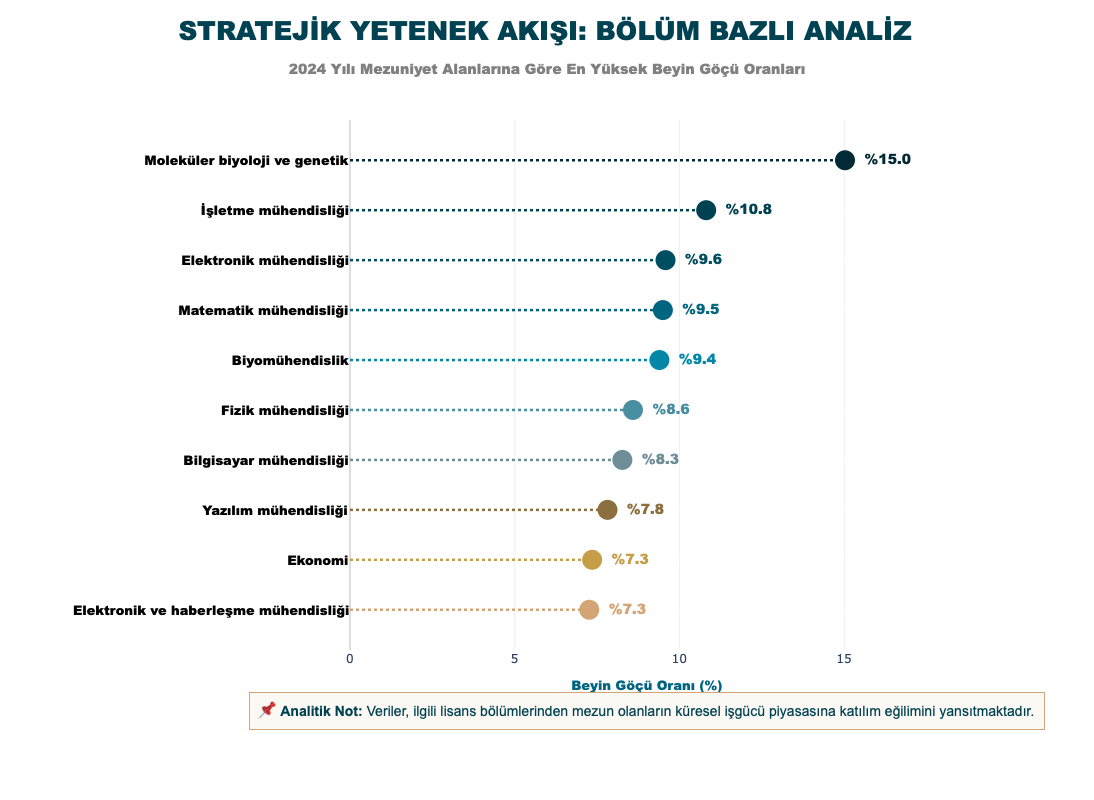

In [27]:
import pandas as pd
import plotly.graph_objects as go

# 1. VERİ OKUMA VE HAZIRLIK
file_name = 'Tamamladıkları bölüme göre yükseköğretim mezunlarının beyin göçü oranı (TR,DF_TAMAMLANAN_BOLUM_BGO,1.0).csv'
df = pd.read_csv(file_name, sep=';')

# Veriyi temizle ve sayıya çevir
df['Gözlem'] = df['Gözlem'].str.replace(',', '.')
df['Gözlem'] = pd.to_numeric(df['Gözlem'], errors='coerce')

# Boş değerleri (nan) temizle (Hata almamak için kritik)
df = df.dropna(subset=['Gözlem'])

# 2024 Yılı - En Yüksek 10 Bölüm (Küçükten büyüğe sıralıyoruz ki grafikte yükselsin)
df_2024 = df[df['Zaman (TIME_PERIOD)'] == 2024]
df_top10 = df_2024.sort_values(by='Gözlem', ascending=True).tail(10)

# 2. FSMVÜ KURUMSAL RENK PALETİ (Premium Geçişli)
# Petrolden Altına doğru prestijli bir akış
FSMVÜ_PALET = [
    '#D4A574', '#C59E47', '#8B6F3F', '#6D8E96', '#4A8FA1', 
    '#0288A6', '#016480', '#014D61', '#014252', '#012A36'
]

# 3. ZARİF VE ÇEKİCİ LOLLIPOP GRAFİK OLUŞTURMA
fig = go.Figure()

# Her satır için renk ve çizgi detaylarını manuel ayarlıyoruz
for i, (index, row) in enumerate(df_top10.iterrows()):
    color = FSMVÜ_PALET[i % len(FSMVÜ_PALET)]
    
    # Yatay Çizgi (İnce ve Keskin - dash='dot' çekicilik katar)
    fig.add_shape(
        type='line',
        x0=0, y0=row['Bölüm'],
        x1=row['Gözlem'], y1=row['Bölüm'],
        line=dict(color=color, width=2.5, dash="dot"),
    )
    
    # Nokta ve Değer Yazısı (Zarif ve Net)
    fig.add_trace(go.Scatter(
        x=[row['Gözlem']],
        y=[row['Bölüm']],
        mode='markers+text',
        marker=dict(
            color=color, 
            size=22, 
            line=dict(color='white', width=2) # Beyaz hat parlatır
        ),
        text=[f" %{row['Gözlem']:.1f}"],
        textposition="middle right",
        textfont=dict(family="Arial Black", size=14, color=color),
        showlegend=False
    ))

# 4. KURUMSAL TASARIM VE HİZALAMA
fig.update_layout(
    height=800,
    width=1100,
    plot_bgcolor='white',
    paper_bgcolor='white',
    # Sol tarafın kesilmemesi için marjin
    margin=dict(l=350, r=150, t=120, b=150),
    
    # GÖNDERDİĞİN GÖRSELDEKİ GİBİ ESTETİK BAŞLIK
    title={
        'text': "<b>STRATEJİK YETENEK AKIŞI: BÖLÜM BAZLI ANALİZ</b><br><span style='font-size:14px; color:gray;'>2024 Yılı Mezuniyet Alanlarına Göre En Yüksek Beyin Göçü Oranları</span>",
        'y': 0.95, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top',
        'font': {'size': 26, 'family': 'Arial Black', 'color': '#014252'}
    },
    
    # ANLAMLI ANALİTİK NOT
    annotations=[
        dict(
            text="📌 <b>Analitik Not:</b> Veriler, ilgili lisans bölümlerinden mezun olanların küresel işgücü piyasasına katılım eğilimini yansıtmaktadır.",
            showarrow=False, xref="paper", yref="paper",
            x=0.5, y=-0.15,
            font=dict(size=14, color="#014252", family="Arial"),
            xanchor="center",
            bgcolor="rgba(212, 165, 116, 0.08)", # Çok hafif altın arka plan
            bordercolor="#D4A574", borderwidth=1, borderpad=10
        )
    ],
    
    xaxis=dict(
        showgrid=True, gridcolor='#F0F0F0',
        title="Beyin Göçü Oranı (%)",
        title_font=dict(family="Arial Black", size=13, color="#016480"),
        range=[0, df_top10['Gözlem'].max() * 1.2], # Sağdaki rakamların taşmaması için pay
        zeroline=True,
        zerolinecolor='#DDD'
    ),
    
    yaxis=dict(
        tickfont=dict(family="Arial Black", size=13, color="black"),
        title=""
    )
)


fig.show()

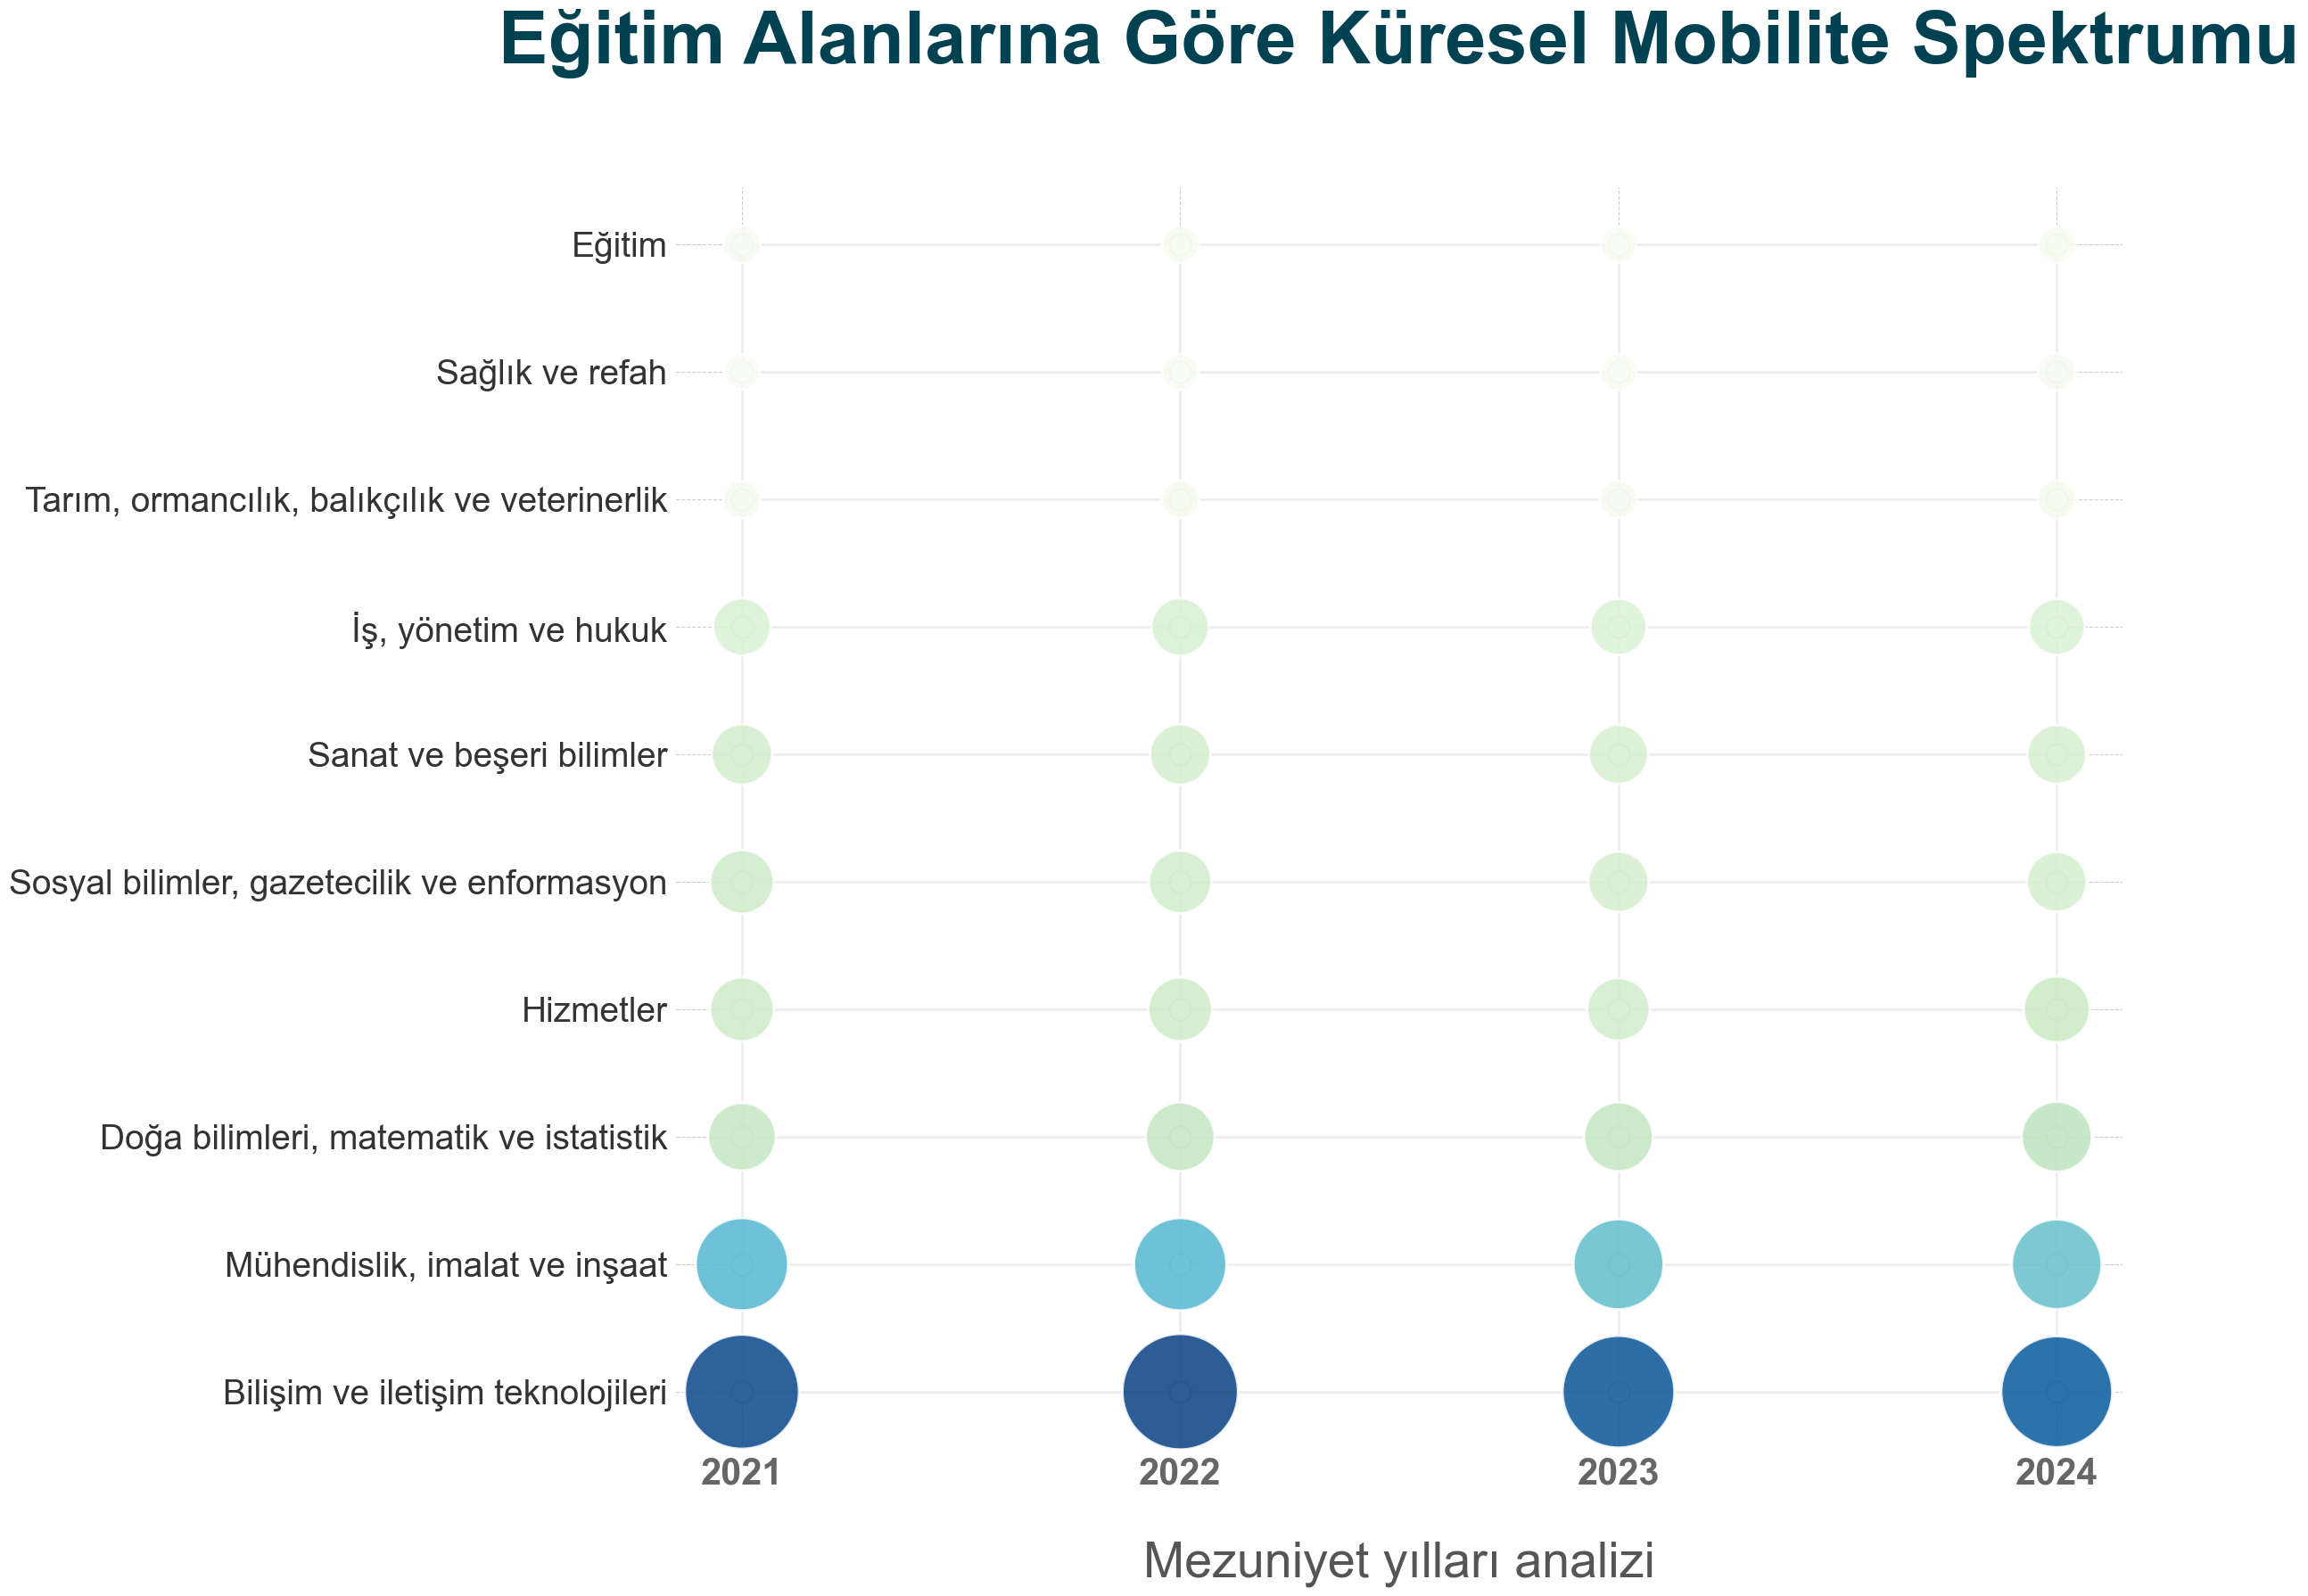

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. VERİ OKUMA VE HAZIRLIK
file_path = 'Eğitim ve öğretim alanlarına göre yükseköğretim mezunlarının beyin göçü oranı (TR,DF_EGITIM_OGRETIM_ALAN,1.0).csv'
df = pd.read_csv(file_path, sep=';')

# Veriyi temizle ve sayıya çevir
df['Gözlem'] = df['Gözlem'].str.replace(',', '.').astype(float)

# En güncel 10 eğitim alanını seçelim (Analiz kalabalık olmasın diye)
top_alanlar = df[df['Zaman (TIME_PERIOD)'] == 2024].nlargest(10, 'Gözlem')['Eğitim ve Öğretim Alanları (1)'].tolist()
df_filtered = df[df['Eğitim ve Öğretim Alanları (1)'].isin(top_alanlar)].copy()

# 2. GRAFİK KURGUSU (60 ve 40 Punto için devasa boyut)
fig, ax = plt.subplots(figsize=(24, 18), facecolor='white')

# Renk Paleti (Petrol ve Altın Tonları)
fsm_blue = '#014252'
fsm_gold = '#D4A574'

# 3. KILAVUZ ÇİZGİLERİ VE BOŞ NOKTALAR (O meşhur görseldeki yapı)
y_labels = df_filtered['Eğitim ve Öğretim Alanları (1)'].unique()
x_labels = sorted(df_filtered['Zaman (TIME_PERIOD)'].unique())

for y_idx, y_val in enumerate(y_labels):
    # Yatay kılavuz çizgileri
    ax.hlines(y_idx, xmin=min(x_labels), xmax=max(x_labels), color='#EEEEEE', linewidth=2, zorder=1)
    for x_val in x_labels:
        # Dikey kılavuz çizgileri
        if y_idx == 0:
            ax.vlines(x_val, ymin=0, ymax=len(y_labels)-1, color='#EEEEEE', linewidth=2, zorder=1)
        
        # ARKA PLANDAKİ BOŞ BEYAZ NOKTALAR
        ax.scatter(x_val, y_idx, s=300, color='white', edgecolor='#DDDDDD', linewidth=1.5, zorder=2)

# 4. VERİ BALONCUKLARI (Dolu Noktalar)
# Balon boyutu 'Gözlem' değerine göre değişir
scatter = ax.scatter(
    df_filtered['Zaman (TIME_PERIOD)'], 
    df_filtered['Eğitim ve Öğretim Alanları (1)'],
    s=df_filtered['Gözlem'] * 1200, # Balon büyüklük çarpanı
    c=df_filtered['Gözlem'], 
    cmap='GnBu', # Petrol mavisi tonlarında bir geçiş
    alpha=0.85, 
    edgecolor='white', 
    linewidth=2, 
    zorder=3
)

# 5. BAŞLIK VE AÇIKLAMALAR (60/40 Kuralı)
# Başlık: 60 Punto, Bold, İlk Harfler Büyük
plt.title('Eğitim Alanlarına Göre Küresel Mobilite Spektrumu', 
          fontsize=60, fontweight='bold', pad=100, color=fsm_blue)

# Eksenler ve Açıklama: 40 Punto, Tümce düzeni
ax.set_xlabel('Mezuniyet yılları analizi', fontsize=40, labelpad=40, color='#555555')
ax.set_ylabel('', fontsize=40) # Sol taraf zaten etiketli

# Eksen Değerleri
plt.xticks(x_labels, fontsize=30, fontweight='bold', color='#666666')
plt.yticks(range(len(y_labels)), y_labels, fontsize=28, color='#333333')

# Gereksiz çerçeveleri kaldır
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

plt.tight_layout()
plt.savefig("stratejik_bubble_chart.png", dpi=200, bbox_inches='tight')
plt.show()

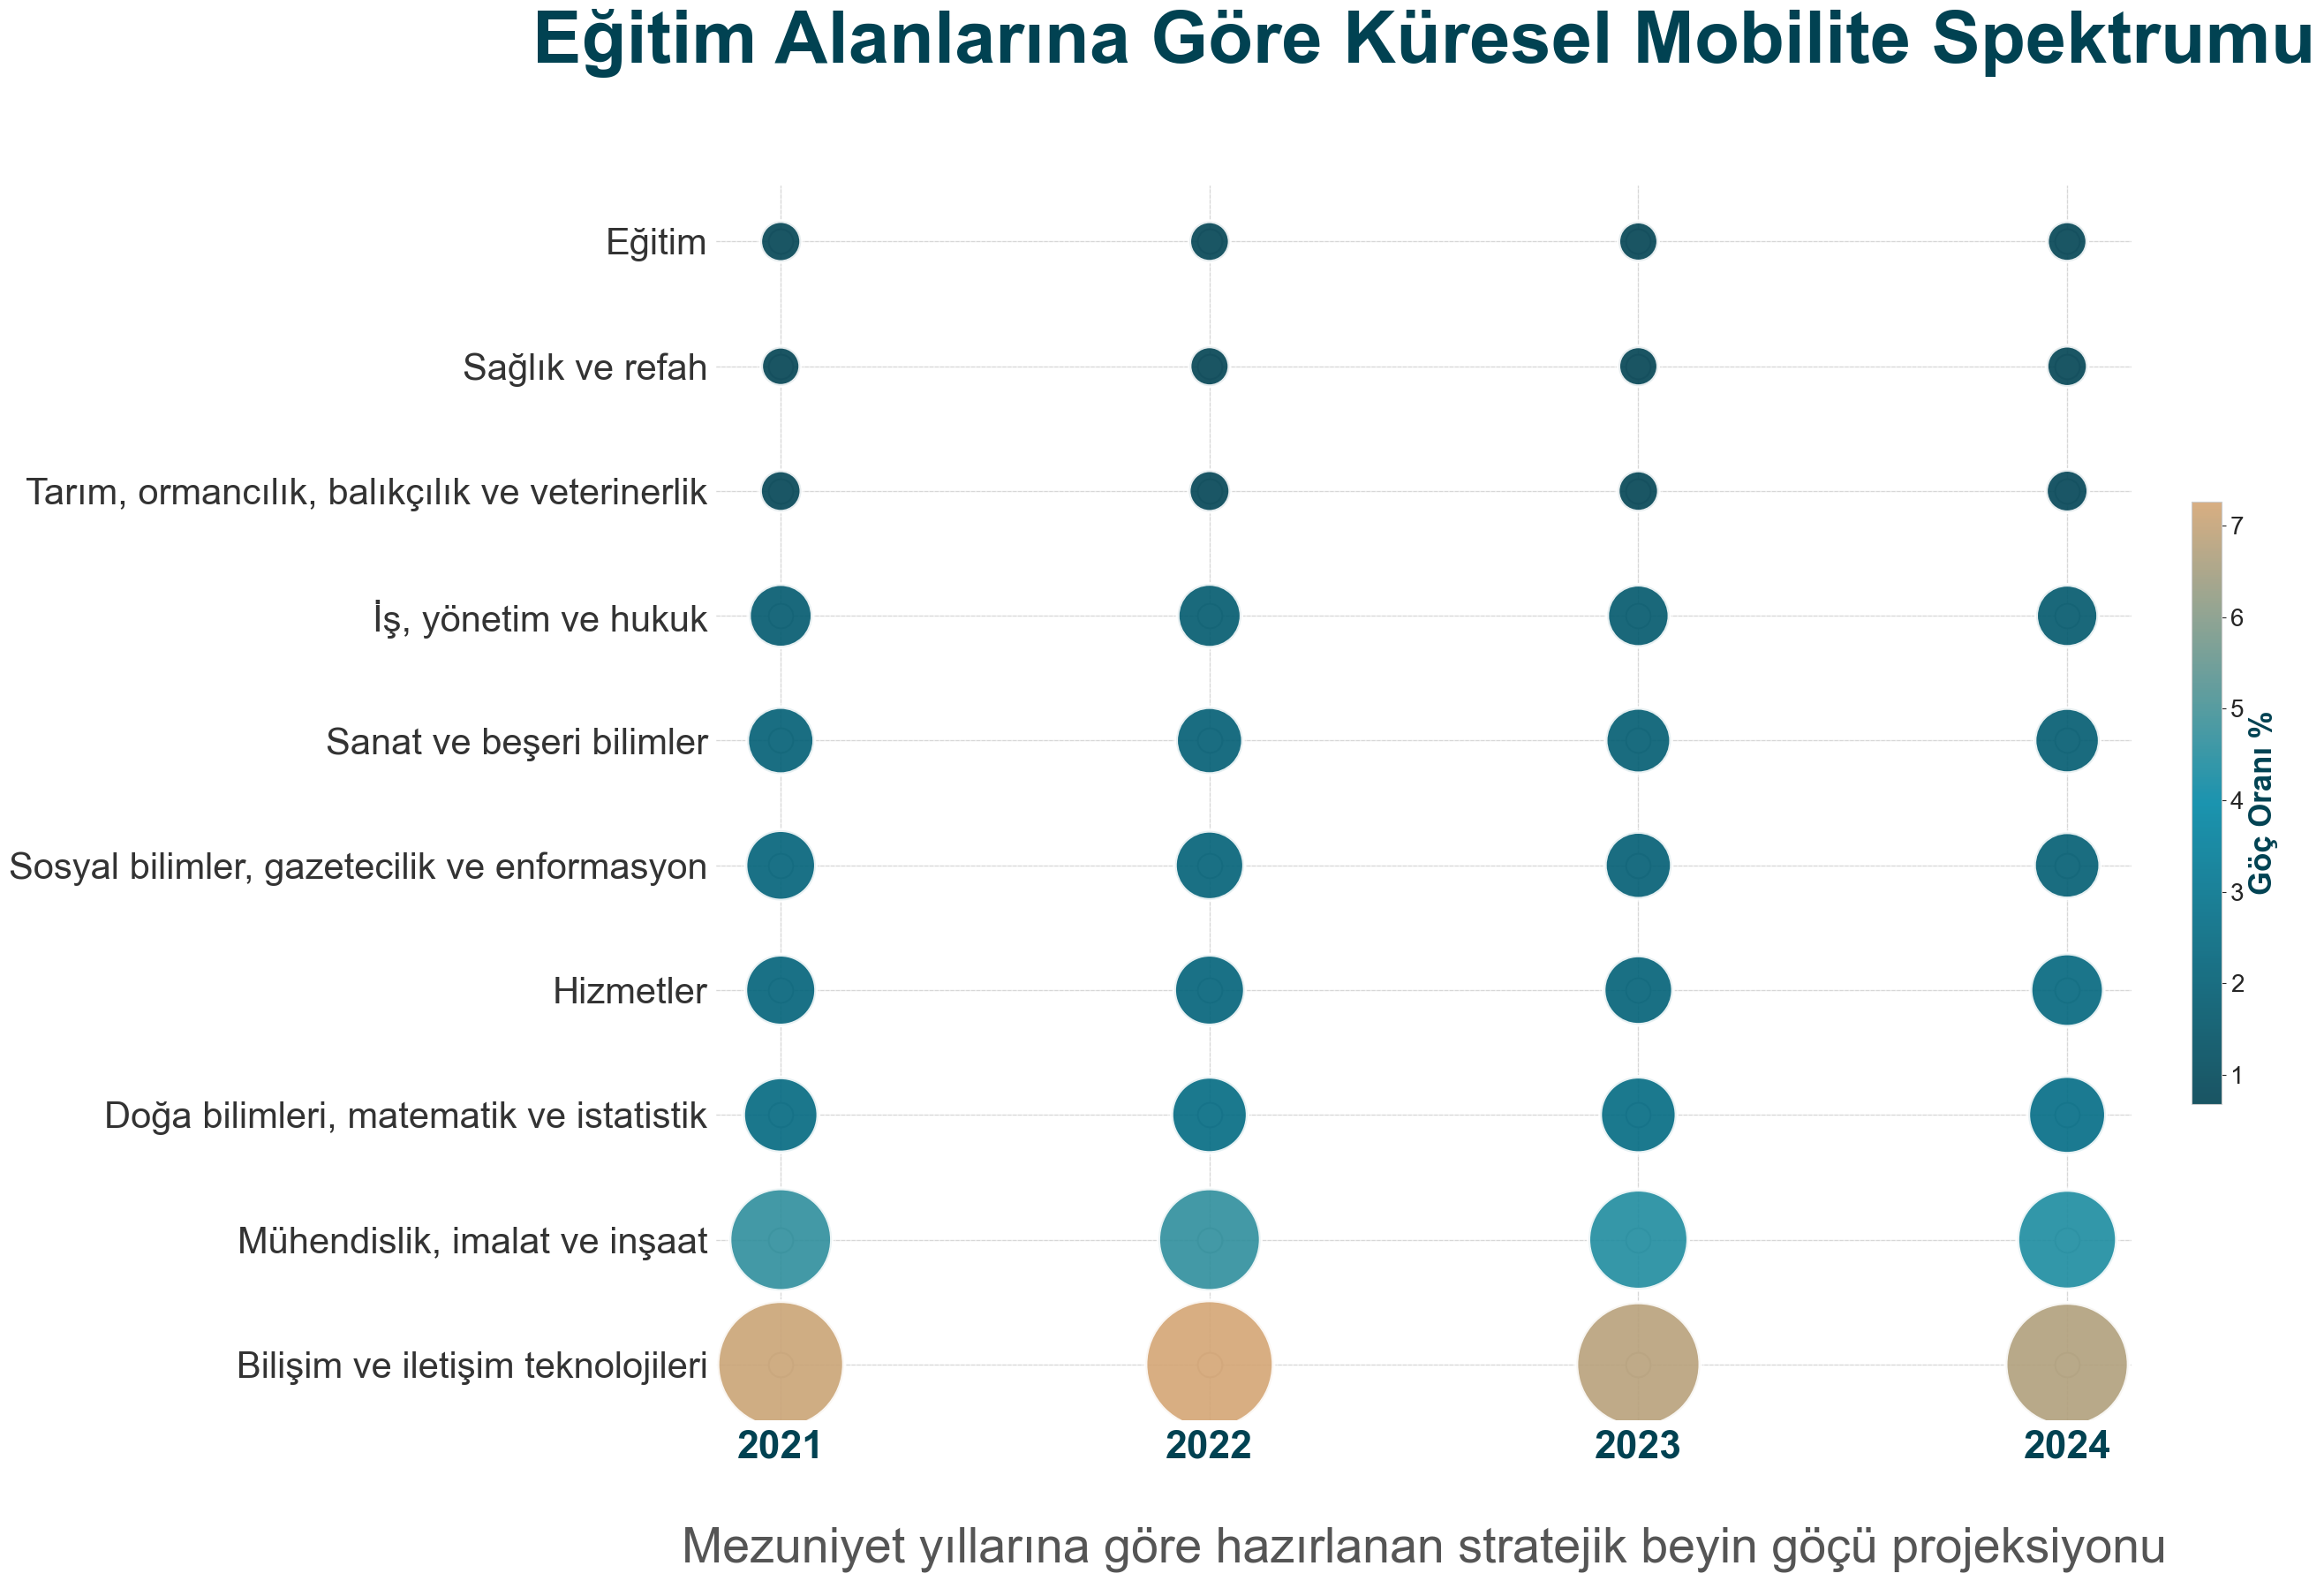

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 1. VERİ OKUMA VE HAZIRLIK
file_path = 'Eğitim ve öğretim alanlarına göre yükseköğretim mezunlarının beyin göçü oranı (TR,DF_EGITIM_OGRETIM_ALAN,1.0).csv'
df = pd.read_csv(file_path, sep=';')
df['Gözlem'] = df['Gözlem'].str.replace(',', '.').astype(float)

# En güncel 10 eğitim alanını seçelim
top_alanlar = df[df['Zaman (TIME_PERIOD)'] == 2024].nlargest(10, 'Gözlem')['Eğitim ve Öğretim Alanları (1)'].tolist()
df_filtered = df[df['Eğitim ve Öğretim Alanları (1)'].isin(top_alanlar)].copy()

# 2. KURUMSAL FSMVÜ RENK PALETİ VE GRADIENT
fsm_petrol = '#014252'
fsm_gold = '#D4A574'
fsm_soft_grey = '#F8F9FA'
custom_cmap = mcolors.LinearSegmentedColormap.from_list("fsm", [fsm_petrol, '#0288A6', fsm_gold])

# 3. GRAFİK KURGUSU (Yüksek Çözünürlük ve Büyük Boyut)
fig, ax = plt.subplots(figsize=(26, 18), facecolor='white')
ax.set_facecolor('white')

y_labels = df_filtered['Eğitim ve Öğretim Alanları (1)'].unique()
x_labels = sorted(df_filtered['Zaman (TIME_PERIOD)'].unique())

# 4. HAVALI "JUNCTION GRID" SİSTEMİ (Arka plandaki o beyaz boş noktalar)
for y_idx, y_val in enumerate(y_labels):
    # Yatay ince kılavuzlar
    ax.hlines(y_idx, xmin=min(x_labels)-0.5, xmax=max(x_labels)+0.5, color='#E0E0E0', linewidth=1, zorder=1, alpha=0.6)
    for x_val in x_labels:
        # Dikey ince kılavuzlar
        if y_idx == 0:
            ax.vlines(x_val, ymin=-0.5, ymax=len(y_labels)-0.5, color='#E0E0E0', linewidth=1, zorder=1, alpha=0.6)
        
        # BOŞ YUVALAR (Görseldeki beyaz birleştirici noktalar)
        ax.scatter(x_val, y_idx, s=400, color='white', edgecolor='#CCCCCC', linewidth=1.5, zorder=2)

# 5. PARLAYAN BALONCUKLAR (Dolu Noktalar)
# Boyutu ve rengi 'Gözlem'e göre ayarlıyoruz
sc = ax.scatter(
    df_filtered['Zaman (TIME_PERIOD)'], 
    df_filtered['Eğitim ve Öğretim Alanları (1)'],
    s=df_filtered['Gözlem'] * 1500, # Daha büyük ve vurucu balonlar
    c=df_filtered['Gözlem'], 
    cmap=custom_cmap,
    alpha=0.9, 
    edgecolor='white', 
    linewidth=3, 
    zorder=3,
    marker='o'
)

# 6. CANVA 60/40 KURALI VE MODERN TİPOGRAFİ
plt.title('Eğitim Alanlarına Göre Küresel Mobilite Spektrumu', 
          fontsize=60, fontweight='bold', pad=100, color=fsm_petrol, family='sans-serif')

# Açıklama (40 Punto Tümce Düzeni)
ax.set_xlabel('Mezuniyet yıllarına göre hazırlanan stratejik beyin göçü projeksiyonu', 
              fontsize=40, labelpad=50, color='#555555', family='sans-serif')

# Eksen Değerleri
plt.xticks(x_labels, fontsize=32, fontweight='bold', color=fsm_petrol)
plt.yticks(range(len(y_labels)), y_labels, fontsize=30, color='#333333')

# Gereksiz çizgileri tamamen temizle
for spine in ax.spines.values():
    spine.set_visible(False)

# Renk çubuğu (Colorbar) - Altın ve Petrol geçişini göstermek için
cbar = plt.colorbar(sc, ax=ax, fraction=0.02, pad=0.04)
cbar.ax.tick_params(labelsize=20)
cbar.set_label('Göç Oranı %', fontsize=25, fontweight='bold', color=fsm_petrol)

plt.tight_layout()

# 7. YÜKSEK ÇÖZÜNÜRLÜKTE KAYIT (400 DPI - Matbaa Kalitesi)
plt.savefig("fsmvu_premium_bubble_matrix.png", dpi=400, bbox_inches='tight')
plt.show()

/var/folders/1y/pf8t4ckj38bfn791ntx85wvr0000gn/T/ipykernel_82095/4206510931.py:26: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



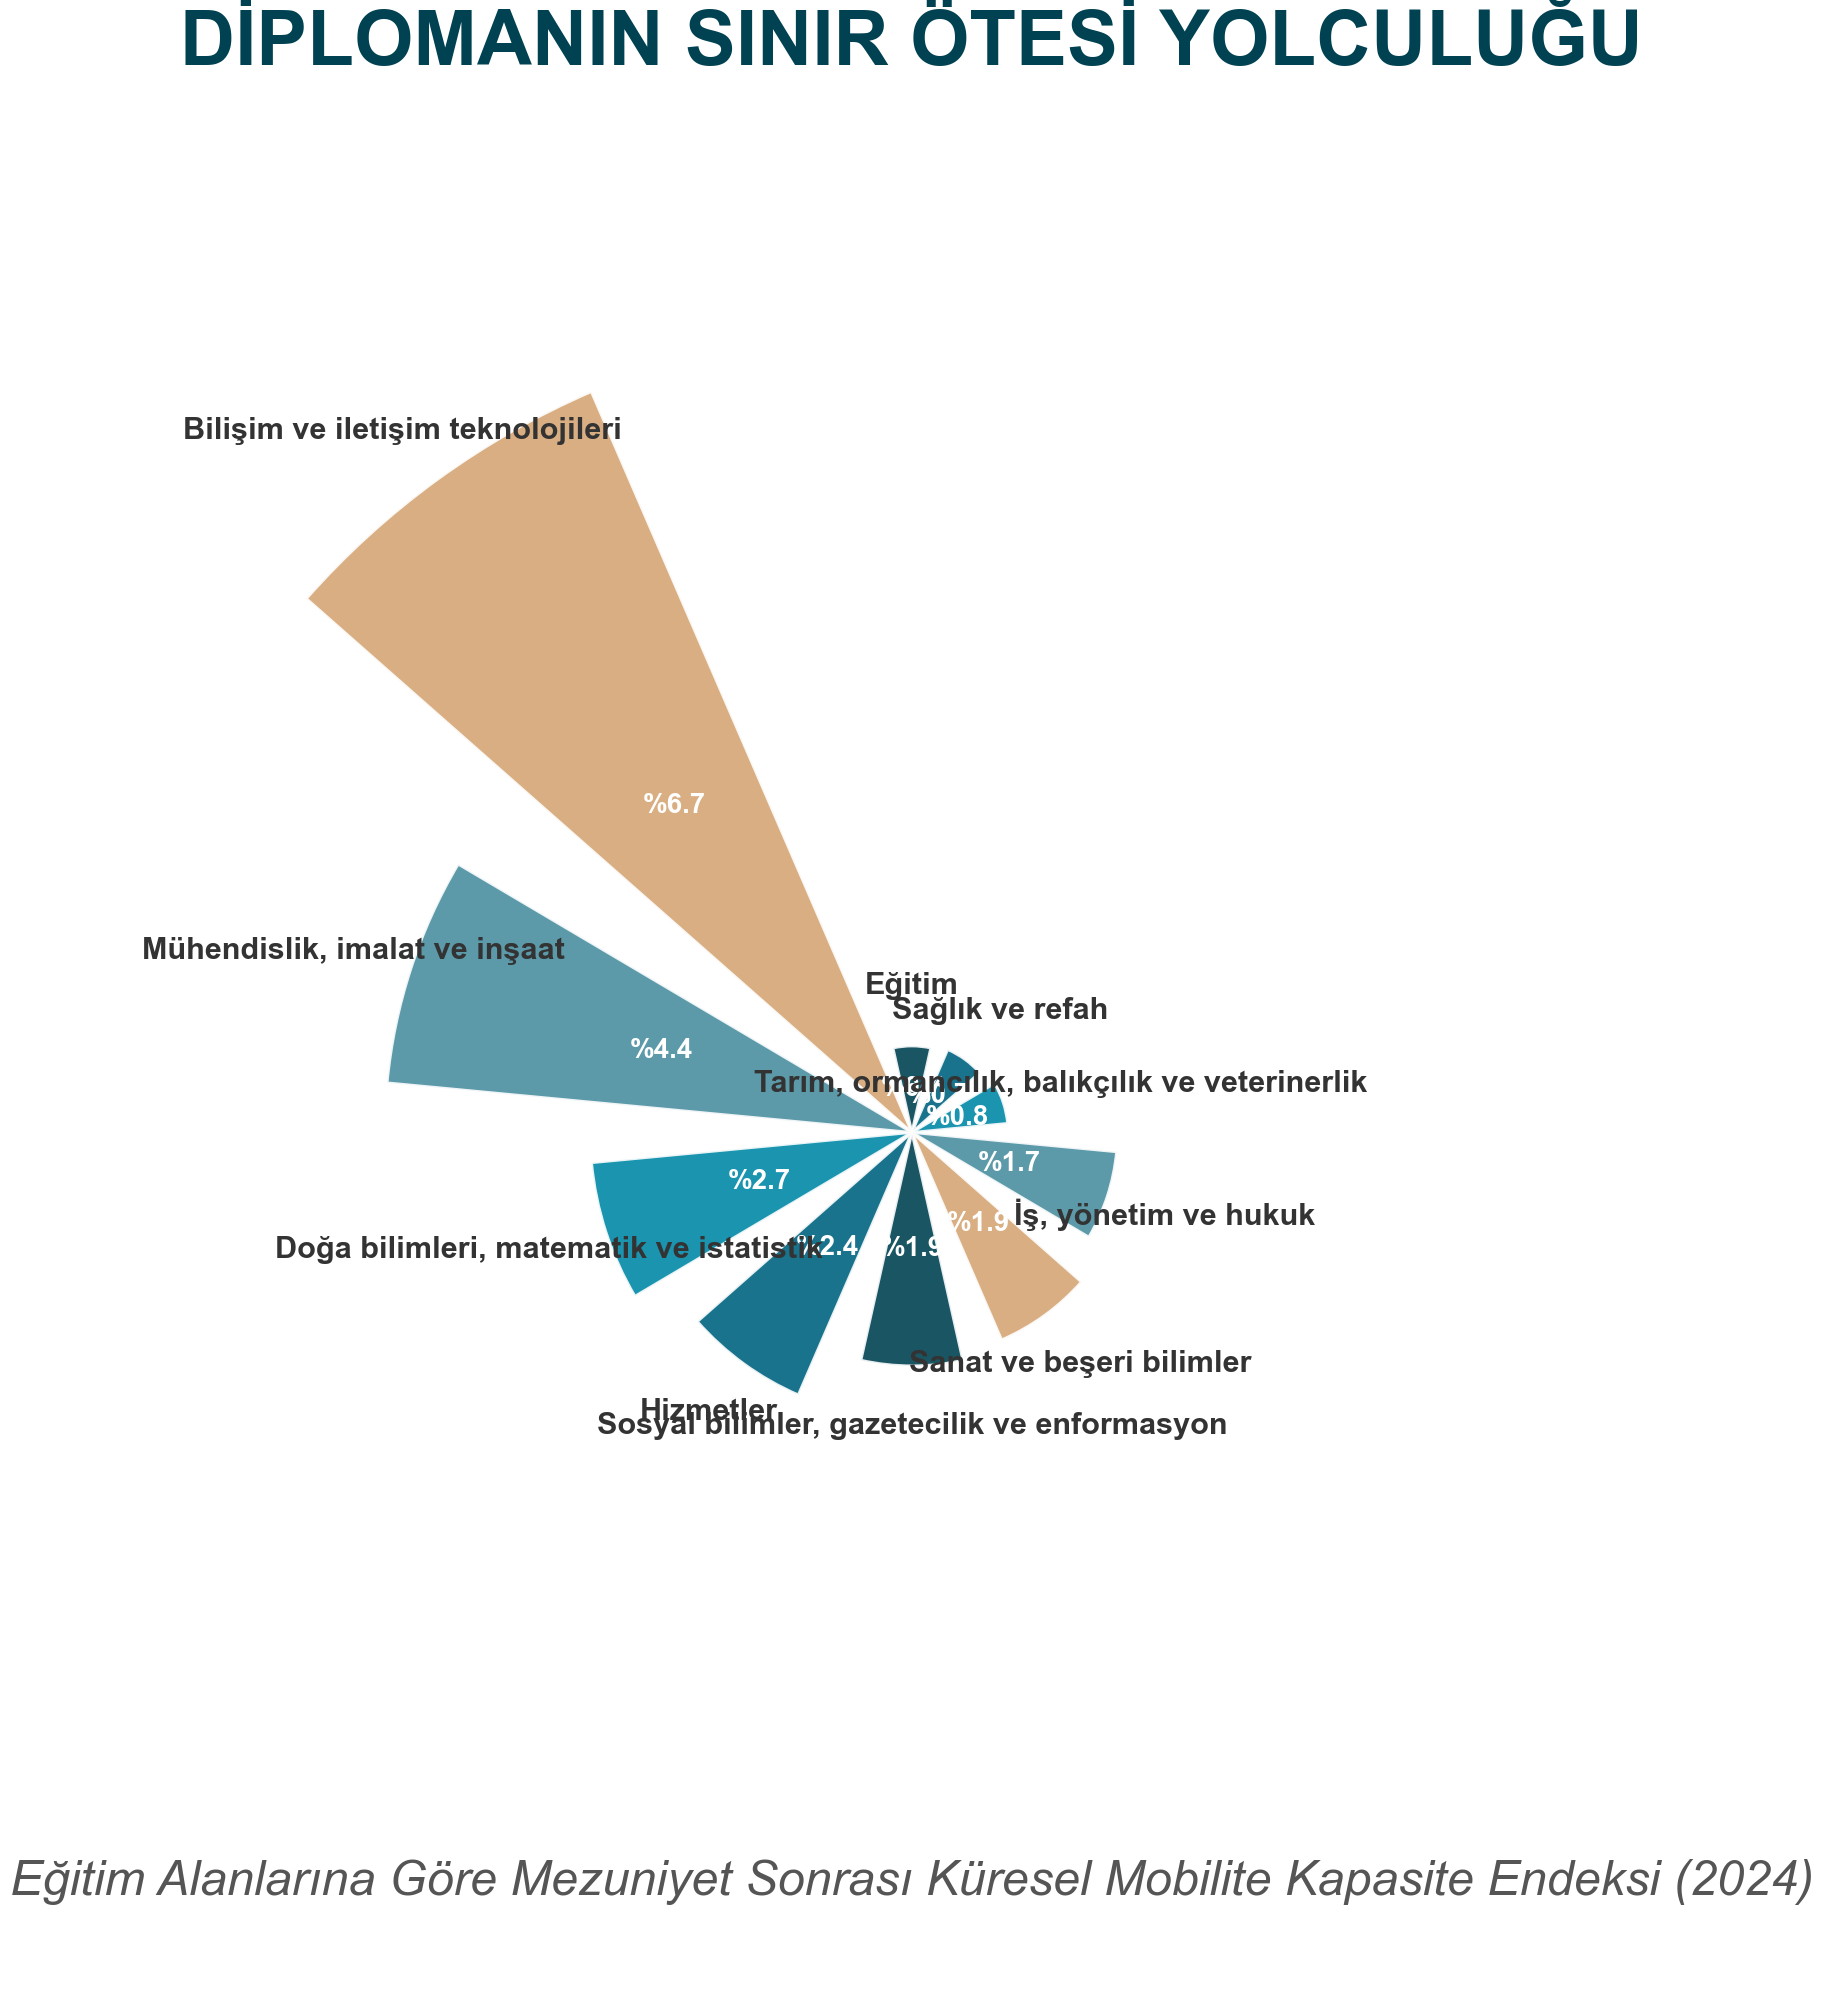

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. VERİ OKUMA VE HAZIRLIK
file_path = 'Eğitim ve öğretim alanlarına göre yükseköğretim mezunlarının beyin göçü oranı (TR,DF_EGITIM_OGRETIM_ALAN,1.0).csv'
df = pd.read_csv(file_path, sep=';')
df['Gözlem'] = df['Gözlem'].str.replace(',', '.').astype(float)

# 2024 yılı verileri
df_2024 = df[df['Zaman (TIME_PERIOD)'] == 2024].nlargest(10, 'Gözlem').sort_values('Gözlem')

# 2. RADIAL (DAİRESEL) TASARIM AYARLARI
labels = df_2024['Eğitim ve Öğretim Alanları (1)'].tolist()
values = df_2024['Gözlem'].tolist()
num_vars = len(labels)

# Açıları hesapla
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
width = (2 * np.pi) / num_vars * 0.7  # Barların kalınlığı

# 3. GÖRSELLEŞTİRME
fig, ax = plt.subplots(figsize=(20, 20), subplot_kw={'projection': 'polar'}, facecolor='white')

# FSMVÜ Renkleri (Koyudan açığa geçişli)
colors = plt.cm.get_cmap('YlGnBu_r')(np.linspace(0.2, 0.6, num_vars)) 
# Not: Manuel petrol ve altın tonları için:
fsm_colors = ['#014252', '#016480', '#0288A6', '#4A8FA1', '#D4A574'] * 2

bars = ax.bar(angles, values, width=width, color=fsm_colors, 
              edgecolor='white', linewidth=2, alpha=0.9)

# 4. 60 PUNTO BAŞLIK (Poster Üstü Etkisi)
plt.title('DİPLOMANIN SINIR ÖTESİ YOLCULUĞU\n', 
          fontsize=55, fontweight='bold', color='#014252', pad=100)

# 40 PUNTO AÇIKLAMA (Alt Bilgi)
fig.text(0.5, 0.05, 
         'Eğitim Alanlarına Göre Mezuniyet Sonrası Küresel Mobilite Kapasite Endeksi (2024)', 
         ha='center', fontsize=35, color='#555555', style='italic')

# 5. ETİKETLER VE ESTETİK
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# Bölüm isimlerini barların ucuna yerleştirme
for angle, value, label in zip(angles, values, labels):
    rotation = np.degrees(angle)
    alignment = "left" if np.pi/2 < angle < 3*np.pi/2 else "right"
    ax.text(angle, value + 0.5, label, 
            ha='center', va='center', rotation=0, # Okunabilirlik için 0 derece
            fontsize=22, fontweight='bold', color='#333333')
    # Değerleri yaz
    ax.text(angle, value / 2, f'%{value:.1f}', 
            ha='center', va='center', fontsize=20, color='white', fontweight='bold')

# Arka planı ve gereksiz çizgileri temizle
ax.set_axis_off() 

plt.tight_layout()
plt.savefig("rektörlük_ozel_radial.png", dpi=300, bbox_inches='tight')
plt.show()

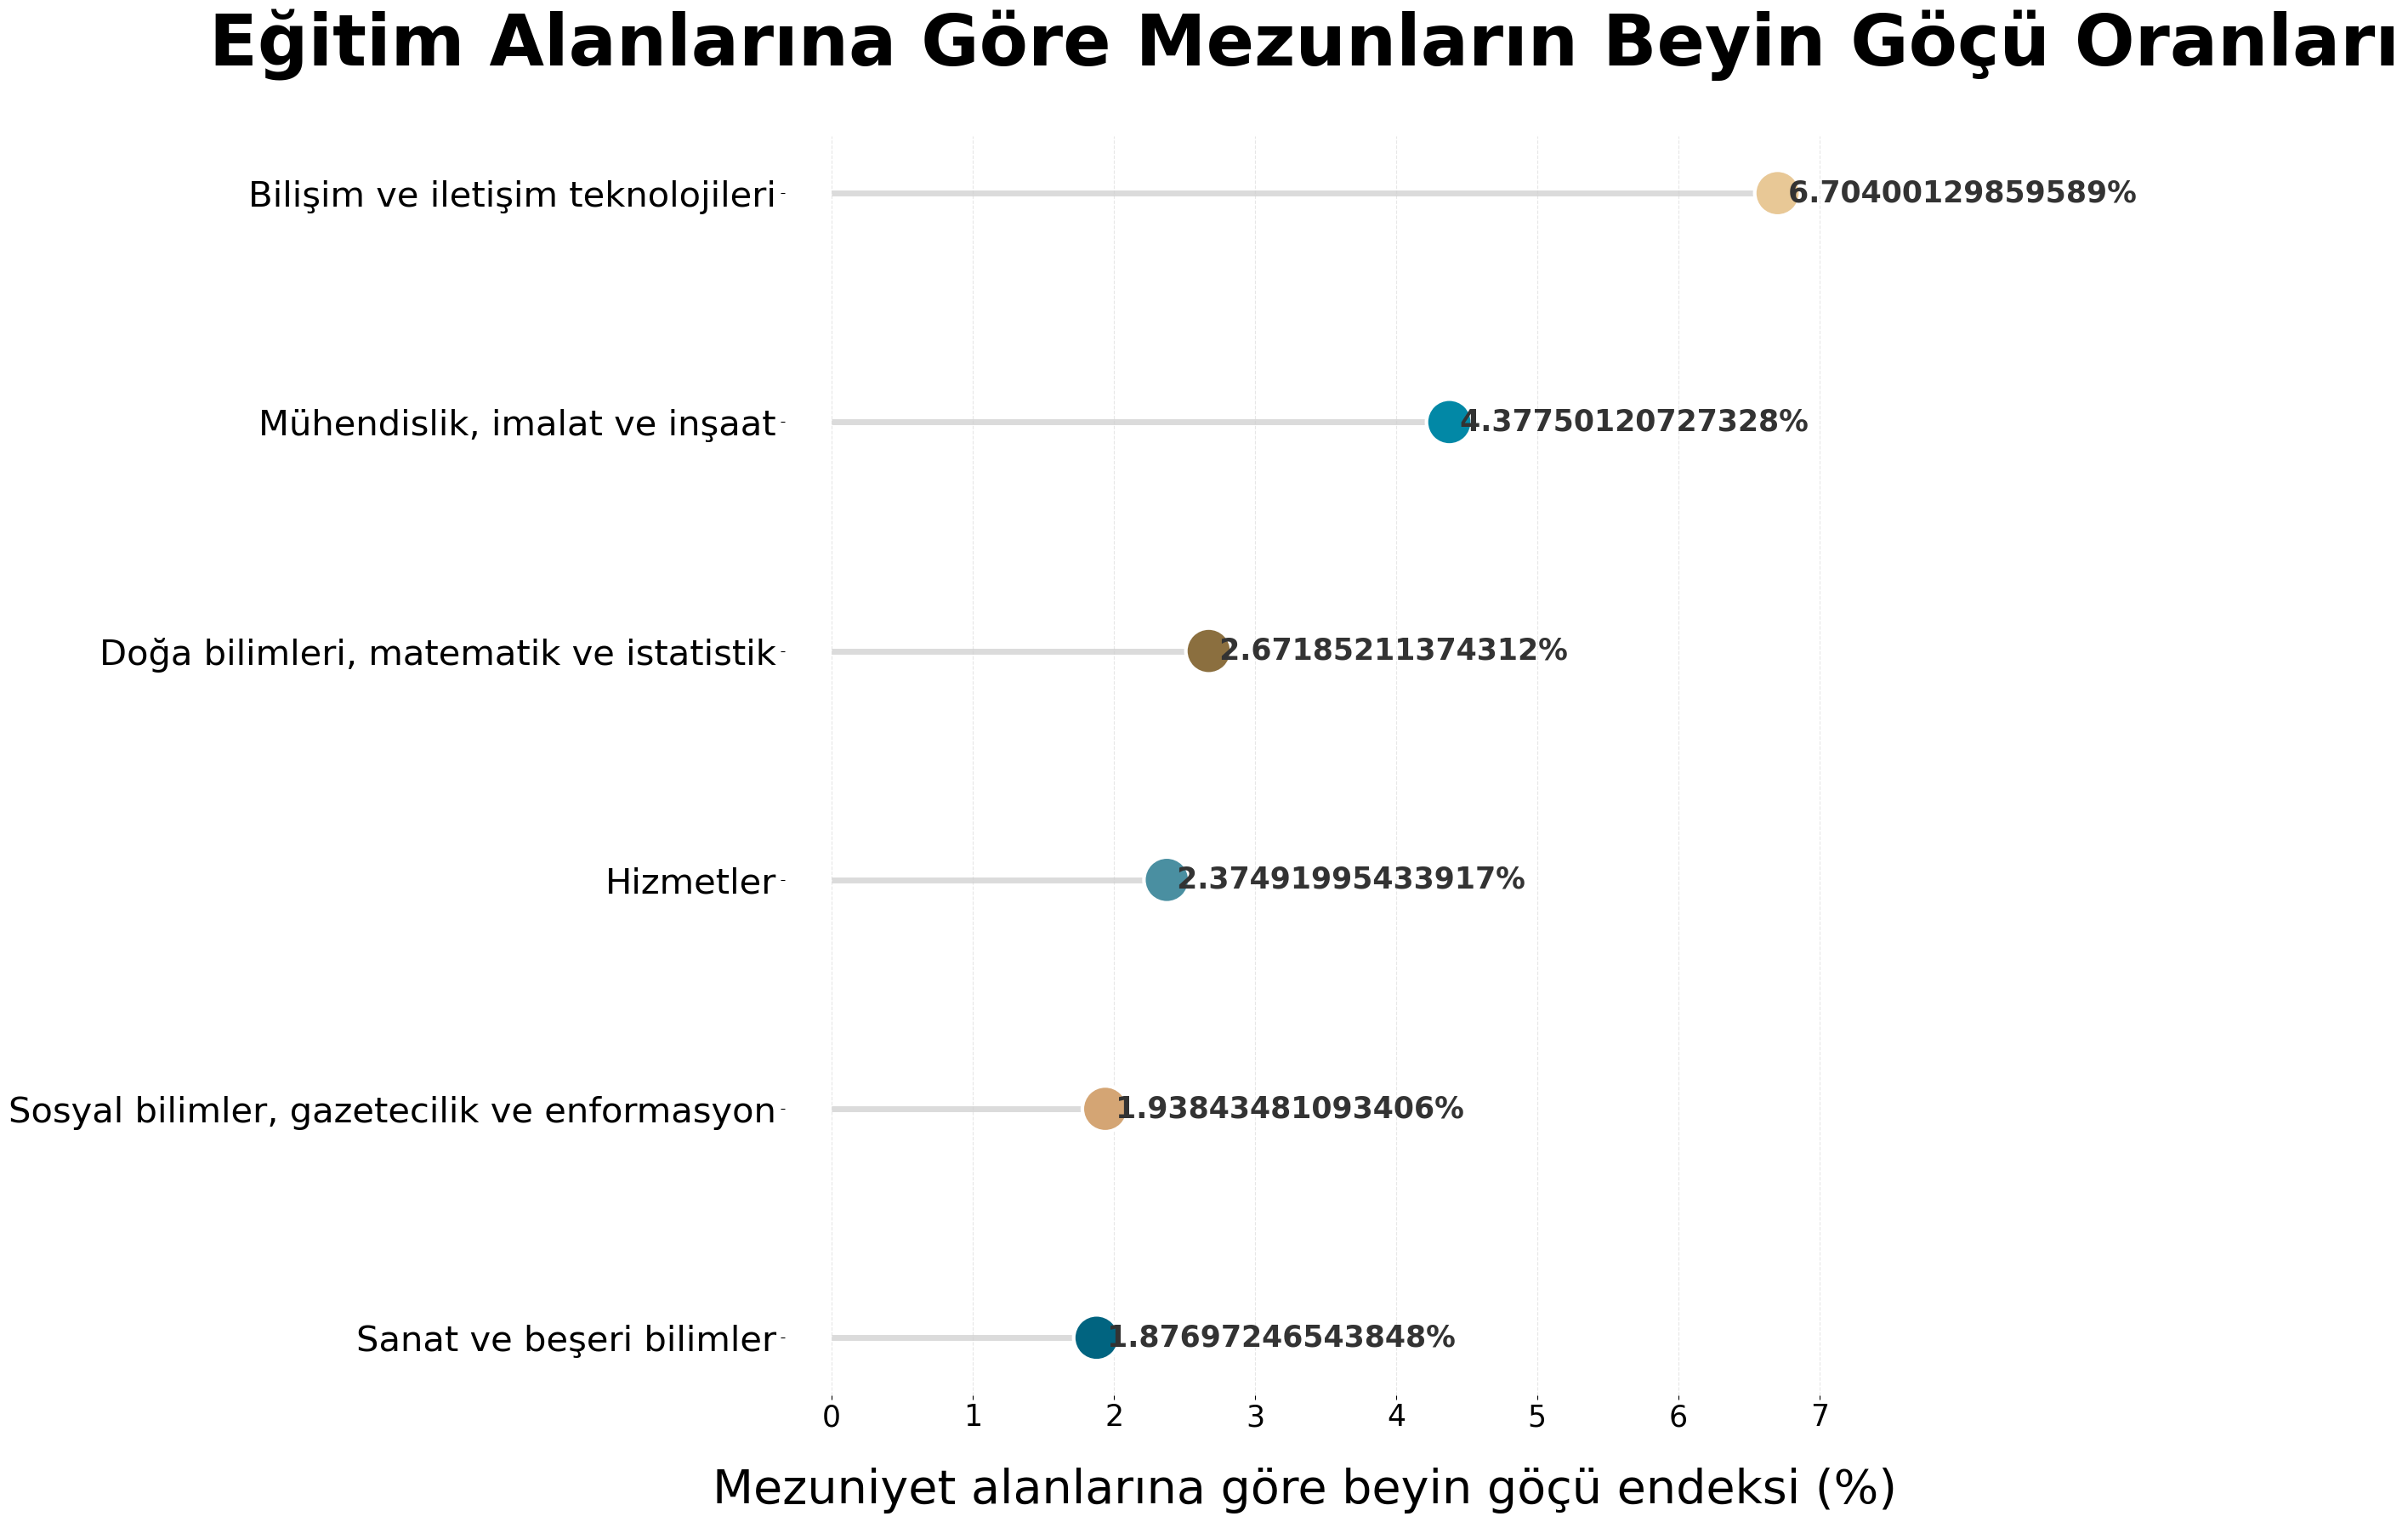

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. VERİ HAZIRLIĞI
file_path = 'Eğitim ve öğretim alanlarına göre yükseköğretim mezunlarının beyin göçü oranı (TR,DF_EGITIM_OGRETIM_ALAN,1.0).csv'
df = pd.read_csv(file_path, sep=';')
df.columns = df.columns.str.strip()
df['Gözlem'] = df['Gözlem'].str.replace(',', '.').astype(float)

# Renk Paleti
FSMVÜ_PALET = ['#016480', '#D4A574', '#4A8FA1', '#8B6F3F', '#0288A6', '#E8C896']

# 2024 verilerini al ve en yüksekten düşüğe sırala
df_plot = df[df['Zaman (TIME_PERIOD)'] == 2024].nlargest(len(FSMVÜ_PALET), 'Gözlem').sort_values('Gözlem')

# 2. GRAFİK OLUŞTURMA
# 60 ve 40 punto çok büyük olduğu için figsize değerini oldukça geniş tutuyoruz
fig, ax = plt.subplots(figsize=(25, 18), facecolor='white')

# Lolipop Çizimi
# Çubuklar (Stem)
ax.hlines(y=df_plot['Eğitim ve Öğretim Alanları (1)'], xmin=0, xmax=df_plot['Gözlem'], 
          color='#CCCCCC', linewidth=5, alpha=0.7)

# Noktalar (Head)
ax.scatter(df_plot['Gözlem'], df_plot['Eğitim ve Öğretim Alanları (1)'], 
           color=FSMVÜ_PALET, s=1500, edgecolors="white", linewidth=3, zorder=3)

# Değerleri noktaların içine veya yanına yazma
for i, val in enumerate(df_plot['Gözlem']):
    ax.text(val, i, f' {val}%', va='center', fontsize=25, fontweight='bold', color='#333333')

# 3. ÖZEL FORMATLAR (BAŞLIK VE AÇIKLAMA)

# Başlık: Bold, 60 punto, Her Kelimenin İlk Harfi Büyük
ax.set_title('Eğitim Alanlarına Göre Mezunların Beyin Göçü Oranları', 
             fontsize=60, fontweight='bold', pad=60)

# Açıklama (Eksen): 40 punto, tümce düzeni
ax.set_xlabel('Mezuniyet alanlarına göre beyin göçü endeksi (%)', 
             fontsize=40, labelpad=30)

# 4. GÖRSEL DÜZENLEME
ax.tick_params(axis='y', labelsize=30)
ax.tick_params(axis='x', labelsize=25)
sns.despine(left=True, bottom=True)
ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()

# 5. PNG OLARAK KAYDET
# Bu komut çalışınca klasörünüzde "lolipop_grafigi.png" oluşacaktır.
plt.savefig("lolipop_grafigi.png", dpi=300, bbox_inches='tight')

plt.show()

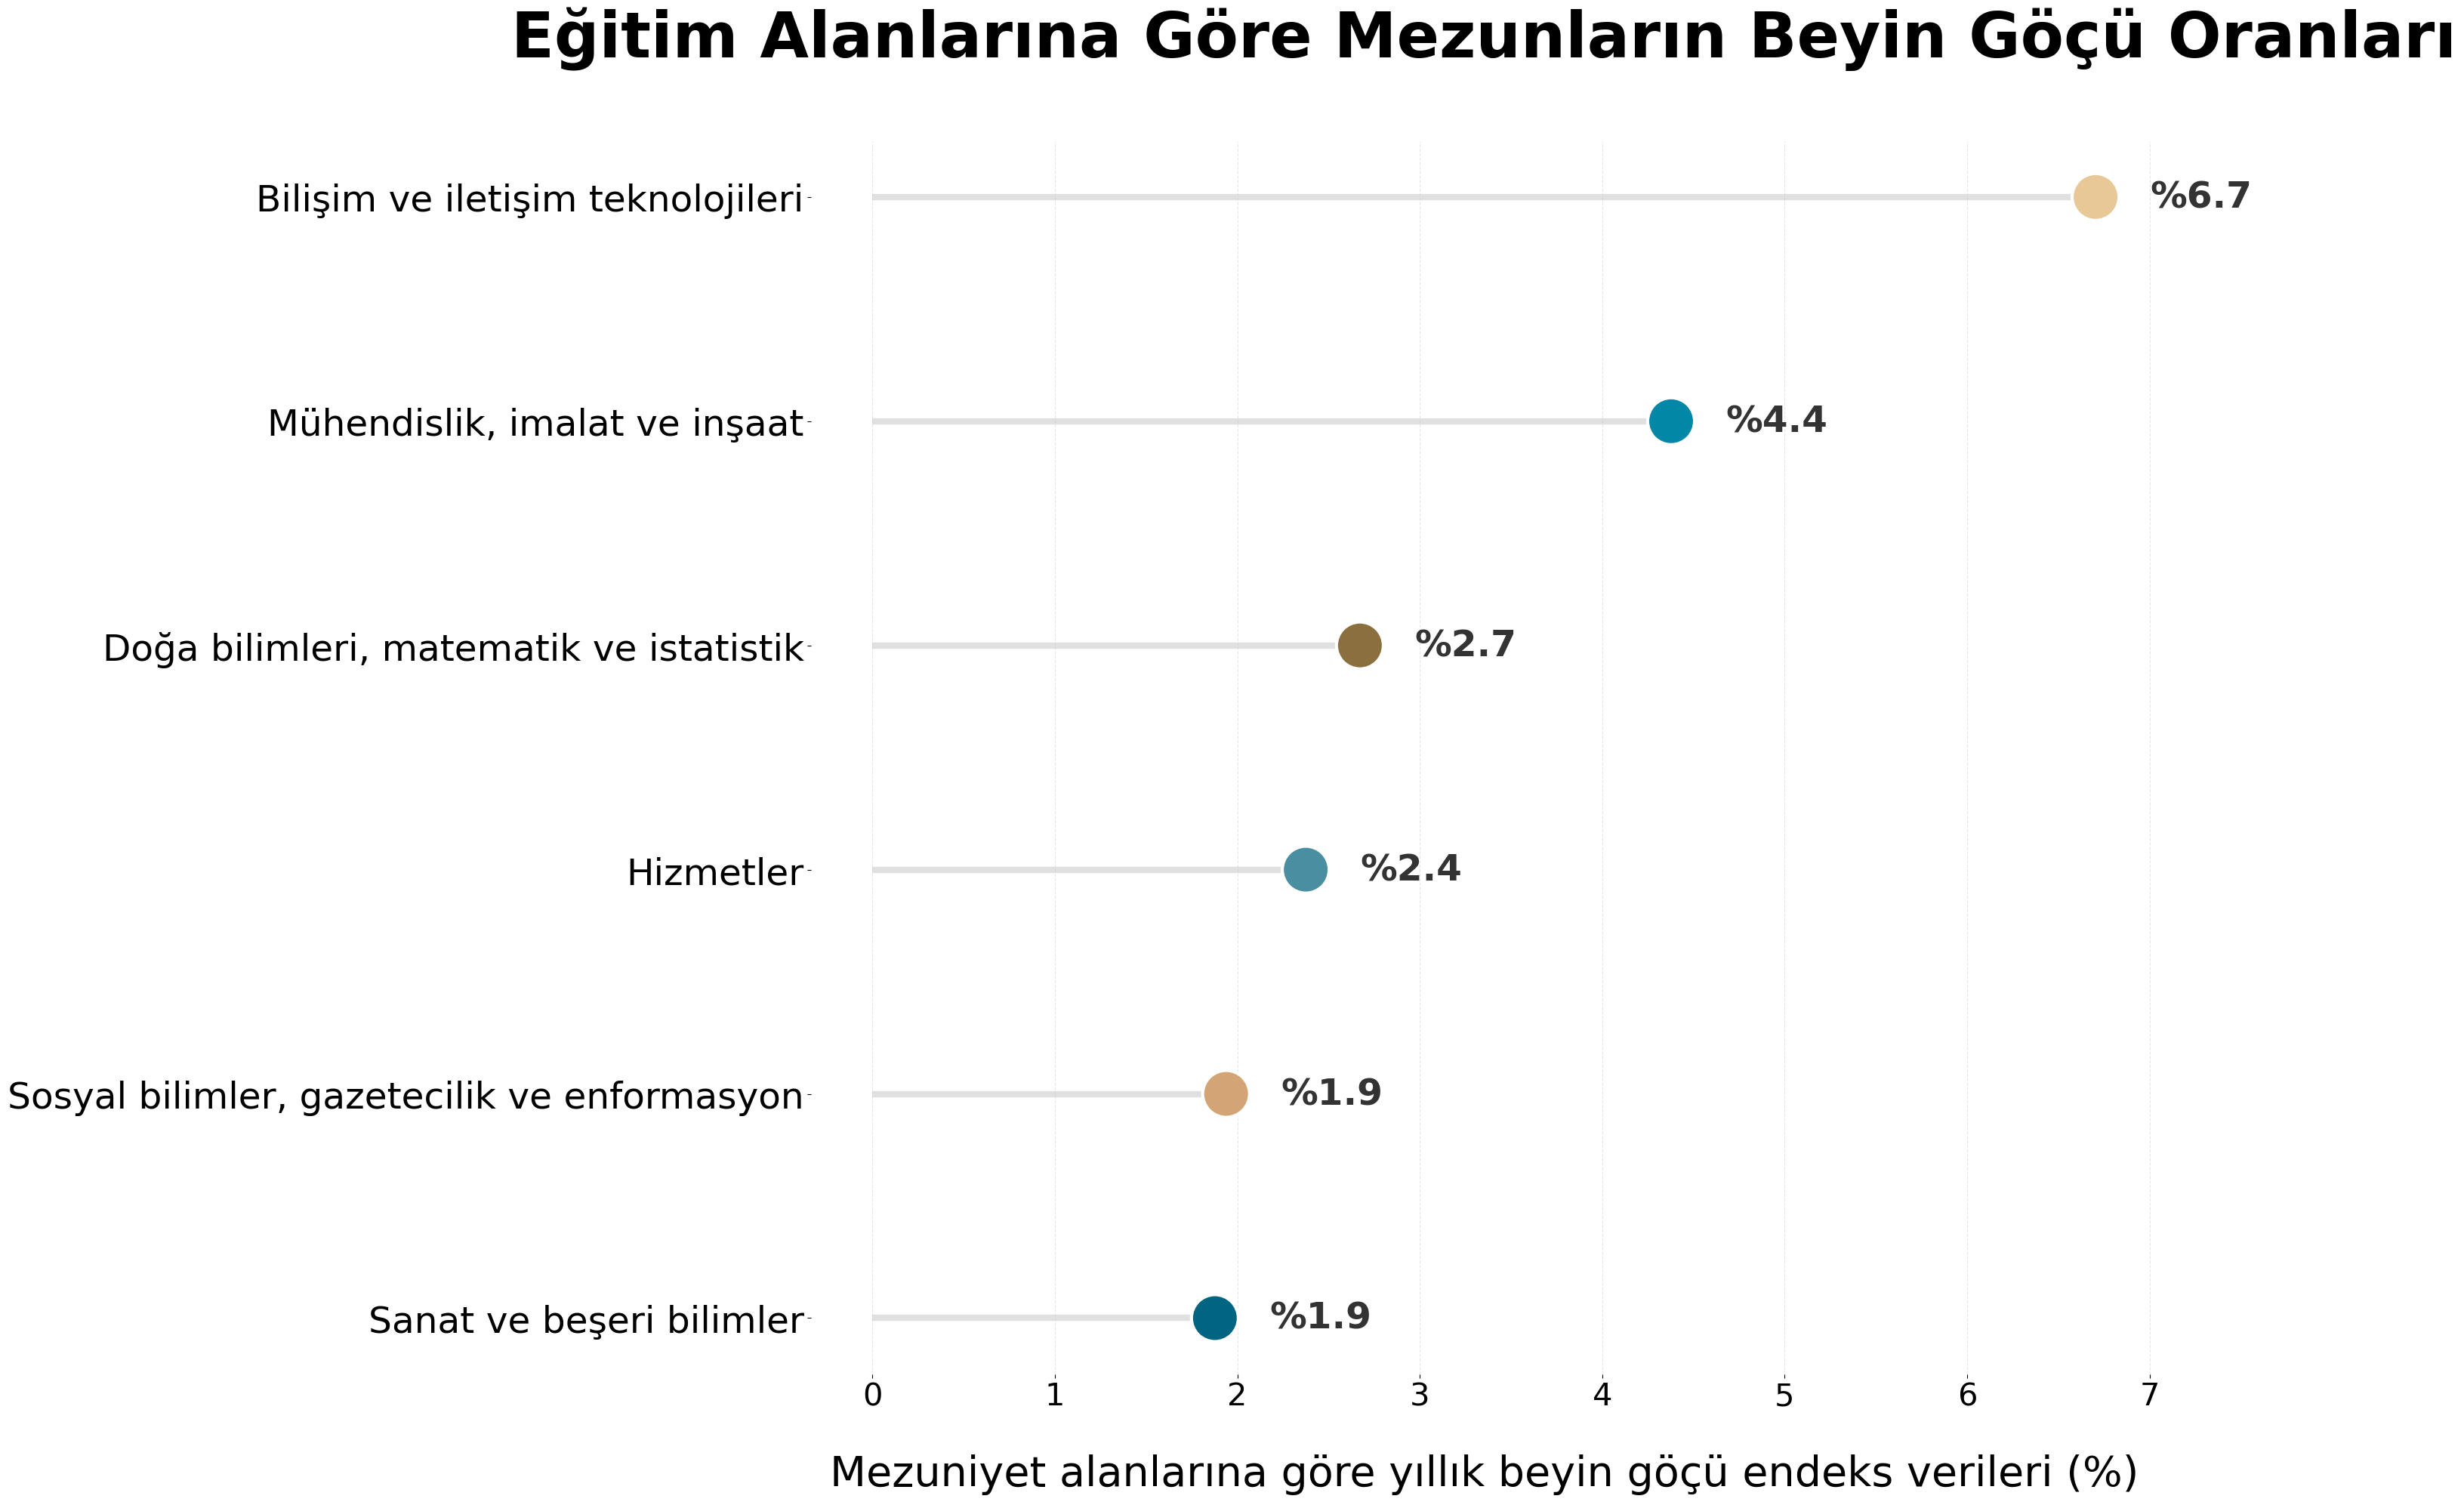

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. VERİ HAZIRLIĞI
file_path = 'Eğitim ve öğretim alanlarına göre yükseköğretim mezunlarının beyin göçü oranı (TR,DF_EGITIM_OGRETIM_ALAN,1.0).csv'
df = pd.read_csv(file_path, sep=';')
df.columns = df.columns.str.strip()
df['Gözlem'] = df['Gözlem'].str.replace(',', '.').astype(float)

# Renk Paleti ve Veri Filtreleme
FSMVÜ_PALET = ['#016480', '#D4A574', '#4A8FA1', '#8B6F3F', '#0288A6', '#E8C896']
df_plot = df[df['Zaman (TIME_PERIOD)'] == 2024].nlargest(len(FSMVÜ_PALET), 'Gözlem').sort_values('Gözlem')

# 2. GRAFİK OLUŞTURMA (Yüksek Punto İçin Büyük Boyut)
fig, ax = plt.subplots(figsize=(30, 20), facecolor='white')

# Lolipop Çizimi
# Çubuklar
ax.hlines(y=df_plot['Eğitim ve Öğretim Alanları (1)'], xmin=0, xmax=df_plot['Gözlem'], 
          color='#CCCCCC', linewidth=6, alpha=0.6)

# Noktalar
ax.scatter(df_plot['Gözlem'], df_plot['Eğitim ve Öğretim Alanları (1)'], 
           color=FSMVÜ_PALET, s=2000, edgecolors="white", linewidth=3, zorder=3)

# --- SAYI YAZMA KISMI ---
for i, val in enumerate(df_plot['Gözlem']):
    # val + 0.2 ifadesi sayıyı noktanın biraz sağına kaydırır
    ax.text(val + 0.3, i, f'%{val:.1f}', 
            va='center', 
            fontsize=35,       # Sayıların büyüklüğü
            fontweight='bold', 
            color='#333333')

# 3. ÖZEL FORMATLAR (İSTEĞİNİZE GÖRE)

# Başlık: BOLD, 60 PUNTO, HER KELİME BÜYÜK
ax.set_title('Eğitim Alanlarına Göre Mezunların Beyin Göçü Oranları', 
             fontsize=60, fontweight='bold', pad=80)

# Açıklama (Alt Eksen): 40 PUNTO, TÜMCE DÜZENİ
ax.set_xlabel('Mezuniyet alanlarına göre yıllık beyin göçü endeks verileri (%)', 
             fontsize=40, labelpad=40)

# 4. EKSEN VE GÖRSEL AYARLAR
ax.tick_params(axis='y', labelsize=35) # Y ekseni yazı boyutu
ax.tick_params(axis='x', labelsize=30) # X ekseni sayı boyutu
sns.despine(left=True, bottom=True)
ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()

# 5. PNG OLARAK KAYDETME
plt.savefig("lolipop_sayili_grafik.png", dpi=300, bbox_inches='tight')

plt.show()